## 12. Zeitreihen in der Prozessüberwachung und -steuerung

[Data Science Playlist auf YouTube](https://www.youtube.com/watch?v=yfgE0GheCWY&list=PLLBUgWXdTBDg1Qgmwt4jKtVn9BWh5-zgy)
[![Python Data Science](https://apmonitor.com/che263/uploads/Begin_Python/DataScience12.png)](https://www.youtube.com/watch?v=yfgE0GheCWY&list=PLLBUgWXdTBDg1Qgmwt4jKtVn9BWh5-zgy "Python Data Science")

**Zeitreihen** entstehen durch fortlaufende Prozesse, wenn neue Messungen aufgezeichnet werden. Aus den Daten abgeleitete Modelle geben Einblick, was als Nächstes passiert. Sie zeigen auch, wie das System verändert werden kann, um ein anderes zukünftiges Ergebnis zu erreichen.

Im Bereich der Produktion und Verfahrenstechnik gibt es zum Teil Datensätze aus Jahrzehnten zu den technischen Anlagen.

Zeitreihenmodelle sind wiederum eine Darstellung eines dynamischen Systems (zBsp ein Reaktor) in diskreter Zeit. Ein Modell eines Prozesses in Zeitreihenform zu bringen, ist die Grundlage vieler Methoden in der Prozessautomation. 

Ein **Digital Twin** ist eine virtuelle Darstellung eines Prozesses, die parallel zum physikalischen System läuft. Ein Zeitreihenmodell kann im engeren Sinne als Digital Twin betrachtet werden, wenn nur bestimmte Eingaben und Ausgaben im Modell enthalten sind. Unten steht das Zeitreihenmodell mit einem einzelnen Eingang ``u`` und einem einzelnen Ausgang ``y``, wobei ``k`` ein Index ist, der sich auf den Zeitschritt bezieht.

$y_{k+1} = \sum_{i=1}^{n_a} a_i y_{k-i+1} + \sum_{i=1}^{n_b} b_i u_{k-i+1}$

Zeitreihenmodelle werden zur System-Identifikation und Regelung eingesetzt und bilden die Grundlage für tiefergehende Anwendungen. Weitere Informationen zu spezifischen Typen von Zeitreihen- und dynamischen Modellen findest du hier:
[ARX (Auto-Regressive eXogenous inputs)](https://apmonitor.com/wiki/index.php/Apps/ARXTimeSeries), [diskreter Zustandsraum](https://apmonitor.com/wiki/index.php/Apps/DiscreteStateSpace) und [kontinuierlicher Zustandsraum](https://apmonitor.com/wiki/index.php/Apps/LinearStateSpace).

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### Zeitreihenantwort ``y`` bei Eingangssprung ``u`` vorhersagen

Ähnlich wie bei Differentialgleichungsmodellen kann ein Zeitreihenmodell eine Eingabe (Feature) haben, die sich durch eine exogene Quelle ändert – etwa aktiv durch einen Messsensor, manuell durch eine Person oder automatisch durch einen Computer.
Wir verwenden hier ein einfaches Zeitreihenmodell mit folgender Formel, die das Verhalten des Systems beschreibt.

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

Berechne die Antwort `y`, wenn der Eingang `u` sich bei `k=5` von `0` auf `100` ändert.
Verwende die Modellgrößen $n_a$=3, $n_b$=1, $n_u$=1, und $n_y$=1.
Das Zeitreihenmodell lautet:

$y_{k+1} = a_1 \, y_k + a_2 \, y_{k-1} + a_3 \, y_{k-2} + b_1 \, u_k$

| **Parameter** | **Wert** |
| ----------- | ----------- |
| $a_1$ | 0.6 |
| $a_2$ | -0.15 |
| $a_3$ | 0.46 |
| $b_1$ | 0.08 |

Anfangsbedingung: $y_0, y_1, y_2 = 0$. Rechne bis $k=100$.
Trage in der Schleife die Zeitreihengleichung ein.


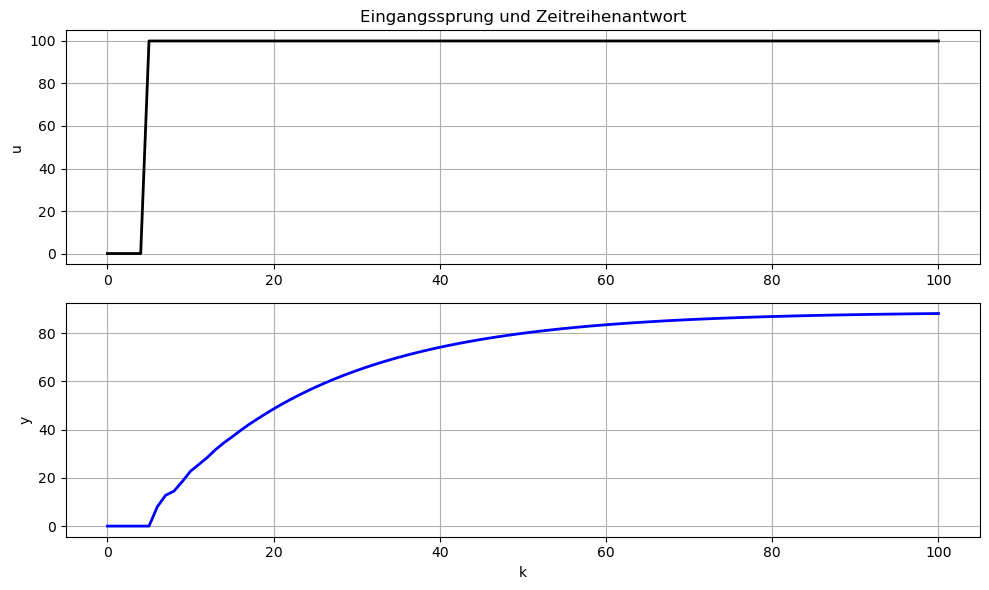

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

n = 101
t = np.arange(n)

# Eingangssignal: Sprung bei k=5 von 0 auf 100
u = np.zeros(n)
u[5:] = 100

# Ausgangssignal
y = np.zeros(n)

# Modellparameter
a = [0.6, -0.15, 0.46]
b = [0.08]

# Zeitreihenmodell:
# y_{k+1} = a1*y_k + a2*y_{k-1} + a3*y_{k-2} + b1*u_k
for k in range(2, n - 1):
    y[k+1] = (
        a[0] * y[k]
        + a[1] * y[k-1]
        + a[2] * y[k-2]
        + b[0] * u[k]
    )

# Darstellung von Eingang und Ausgang
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, u, 'k-', linewidth=2)
plt.ylabel('u')
plt.title('Eingangssprung und Zeitreihenantwort')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, y, 'b-', linewidth=2)
plt.xlabel('k')
plt.ylabel('y')
plt.grid(True)

plt.tight_layout()
plt.show()

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Zeitreihen-Regression

Nachdem du ein Zeitreihenmodell simuliert hast, besteht der nächste Schritt darin, die Koeffizienten aus Daten zu bestimmen. Dafür gibt es in Gekko die Funktion `sysid`, die die Systemidentifikation eines Zeitreihenmodells automatisiert.

![gekko](https://apmonitor.com/che263/uploads/Begin_Python/gekko.png)

Du kannst die Hilfe zu dieser Funktion mit `help(m.sysid)` aufrufen. Ein Teil der Hilfe ist unten gezeigt.

    y,p,K = sysid(t,u,y,na=1,nb=1,shift='calc',pred='model')

    Input:     t = time data
               u = input data for the regression
               y = output data for the regression   
               na   = number of output coefficients (default=1)
               nb   = number of input coefficients (default=1)
               nk   = input delay steps (default=0)
               shift (optional) = 
                  'none' (no shift)
                  'init' (initial pt),
                  'mean' (mean center)
                  'calc' (calculate c)
               pred (option) = 
                  'model' for output error regression form, implicit solution
                  'meas' for ARX regression form, explicit solution
                  Using 'model' favors an unbiased model prediction but
                    can require more time to compute, especially for large
                    data sets
                  Using 'meas' computes the coefficients of the time series
                    model with an explicit solution
               
    Output:    returns
               ypred (predicted outputs)
               p as coefficient dictionary with keys 'a','b','c'
               K gain matrix
               

Es gibt viele Optionen, z. B. ``pred`` als ``meas`` oder ``model``. Mit ``meas`` wird der nächste Zeitschritt aus vergangenen Messungen im ``ARX``-Format vorhergesagt. Mit ``model`` werden die bisherigen Modellvorhersagen genutzt, um den nächsten Zeitschritt vorherzusagen. Das wird auch Output-Error (``OE``)-Modell genannt. Bei großen Datensätzen solltest du ``pred=meas`` verwenden, da die Lösung deutlich schneller ist.

Das Wichtigste ist zu entscheiden, wie viele Koeffizienten im Modell enthalten sein sollen, festgelegt über ``na`` und ``nb``. Starte mit kleinen Werten und füge nur dann weitere Koeffizienten hinzu, wenn für höhergradige Dynamik mehr Genauigkeit benötigt wird. Ein weiterer Faktor ist ``shift``: ``init`` ist vorzuziehen, wenn du aus stationären Bedingungen startest. Andernfalls sind ``mean`` oder ``calc`` gute Optionen, um ein unverzerrtes Modell ohne Offset in den Vorhersagen zu erstellen.

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

Ändere die Anzahl der Koeffizienten ``na`` und ``nb`` und beobachte die Genauigkeit der Vorhersagen. Setze außerdem ``na=2`` und ``nb=2`` und ändere ``pred=model``.


```python
na = 2 # Ausgangskoeffizienten
nb = 2 # Eingangskoeffizienten
yp,p,K = m.sysid(t,u,y,na,nb,pred='meas')
```

Wie viel länger dauert das Lösen, wenn du die Anzahl der Koeffizienten erhöhst oder `pred` änderst? Du kannst die Laufzeit einer Funktion messen mit:


```python
import time
start = time.time()
### die Funktion
print('Elapsed time: ' + str(time.time()-start))
```

In [ ]:
from gekko import GEKKO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Daten laden und in Spalten aufteilen
url = 'http://apmonitor.com/pdc/uploads/Main/tclab_data4.txt'
data = pd.read_csv(url)
t = data['Time']
u = data['Q1']
y = data['T1']

# Zeitreihen-Modell generieren
m = GEKKO(remote=False)

# Systemidentifikation
na = 2 # Ausgangskoeffizienten
nb = 2 # Eingangskoeffizienten
yp,p,K = m.sysid(t,u,y,na,nb,pred='meas')

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(t,u)
plt.legend([r'$Q_1$ (%)'])
plt.ylabel('MV Heater (%)')
plt.subplot(2,1,2)
plt.plot(t,y,'b-',label=r'$T_{1,meas}$')
plt.plot(t,yp,'r--',label=r'$T_{1,pred}$')
plt.legend(); plt.ylabel('CV Temp (°C)')
plt.xlabel('Time (sec)'); plt.savefig('12-sysid.png')

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### Zeitreihen simulieren

Es kann auch mehrere Eingänge und mehrere Ausgänge geben, z. B. wenn $n_a$=2, $n_b$=1, $n_u$=2, and $n_y$=2.

$y_{1,k+1} = a_{1,1} \, y_{1,k} + a_{2,1} \, y_{1,k-1} + b_{1,1} \, u_{1,k} + b_{1,2} \, u_{2,k}$

$y_{2,k+1} = a_{1,2} \, y_{2,k} + a_{2,2} \, y_{2,k-1} + b_{2,1} \, u_{1,k} + b_{2,2} \, u_{2,k}$

Gekko verfügt über das `arx`-Modell, das identifizierte Zeitreihenmodelle löst. Dafür wird ein Python-Dictionary mit den nachfolgenden Koeffizientenmatrizen benötigt:
$A\in\mathbb{R}^{n_a \, \mathrm{x} \, n_y}$, $B\in\mathbb{R}^{n_y \, \mathrm{x} \, \left(n_b \mathrm{x} n_u\right)}$, and $C\in\mathbb{R}^{n_y}$.
Dieses Dictionary wird mit der Gekko-Funktion `sysid` (Systemidentifikation) automatisch erstellt. Unten folgt ein Beispiel, wie das Dictionary manuell angelegt wird.

```python
    # python dictionary
    p = {'a':A,'b':B,'c':C}
```

$A = \begin{bmatrix}0.36788 & 0.36788 \\ 0.223 & -0.136\end{bmatrix}$
$B = \begin{bmatrix}0.63212 & 0.18964 \\ 0.31606 & 1.2642\end{bmatrix}$
$C = \begin{bmatrix}0 & 0\end{bmatrix}$

[Weitere Gekko-Tutorials](https://apmonitor.com/wiki/index.php/Main/GekkoPythonOptimization) zeigen, wie andere Gleichungstypen gelöst werden und helfen bei weiteren Optimierungsproblemen.  

In [ ]:
import numpy as np
from gekko import GEKKO
import matplotlib.pyplot as plt
%matplotlib inline

na = 2 # Anzahl der A-Koeffizienten
nb = 1 # Anzahl der B-Koeffizienten
ny = 2 # Anzahl der Ausgänge
nu = 2 # Anzahl der Eingänge

# A (na x ny)
A = np.array([[0.36788,0.36788],\
              [0.223,-0.136]]) 
# B (ny x (nb x nu))
B1 = np.array([0.63212,0.18964]).T
B2 = np.array([0.31606,1.26420]).T
B = np.array([[B1],[B2]])

C = np.array([0,0])

# Parameter-Dictionary erstellen
p = {'a':A,'b':B,'c':C}

# GEKKO-Modell erstellen
m = GEKKO(remote=False)

# GEKKO-ARX-Modell erstellen
y,u = m.arx(p)

# Eingänge laden
tf = 20 # Endzeit
u1 = np.zeros(tf+1)
u2 = u1.copy()
u1[5:] = 3.0
u2[10:] = 5.0
u[0].value = u1
u[1].value = u2

# Namen anpassen
mv1 = u[0]; mv2 = u[1]
cv1 = y[0]; cv2 = y[1]

# Optionen
m.time = np.linspace(0,tf,tf+1)
m.options.imode = 4; m.options.nodes = 2

# simulieren
m.solve(disp=False)

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(m.time,mv1.value,'r-',label=r'$MV_1$')
plt.plot(m.time,mv2.value,'b--',label=r'$MV_2$')
plt.ylabel('MV')
plt.legend(loc='best')
plt.subplot(2,1,2)
plt.plot(m.time,cv1.value,'r:',label=r'$CV_1$')
plt.plot(m.time,cv2.value,'b.-',label=r'$CV_2$')
plt.ylabel('CV'); plt.xlabel('Time (sec)')
plt.legend(loc='best')
plt.show()

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### TCLab-Übung

Führe das Skript aus, um Daten für die ARX-Systemidentifikation und den Model Predictive Controller (MPC) zu erzeugen.


![connections](https://apmonitor.com/che263/uploads/Begin_Python/connections.png)

TCLab version 1.0.0
Arduino Leonardo connected on port COM7 at 115200 baud.
TCLab Firmware 2.0.1 Arduino Leonardo/Micro.
Time: 0 Q1: 0.0 Q2: 0.0 T1: 50.579 T2: 37.012
Time: 2 Q1: 0.0 Q2: 0.0 T1: 50.869 T2: 37.012
Time: 4 Q1: 0.0 Q2: 0.0 T1: 50.901 T2: 37.334
Time: 6 Q1: 0.0 Q2: 0.0 T1: 51.191 T2: 37.334
Time: 8 Q1: 0.0 Q2: 0.0 T1: 51.191 T2: 37.366
Time: 10 Q1: 0.0 Q2: 0.0 T1: 51.191 T2: 37.624
Time: 12 Q1: 0.0 Q2: 0.0 T1: 51.191 T2: 37.656
Time: 14 Q1: 0.0 Q2: 0.0 T1: 51.191 T2: 37.656
Time: 16 Q1: 0.0 Q2: 0.0 T1: 51.191 T2: 37.688
Time: 18 Q1: 0.0 Q2: 0.0 T1: 50.901 T2: 37.914
Time: 20 Q1: 80.0 Q2: 0.0 T1: 50.869 T2: 37.979
Time: 22 Q1: 80.0 Q2: 0.0 T1: 50.837 T2: 38.011
Time: 24 Q1: 80.0 Q2: 0.0 T1: 50.579 T2: 38.011
Time: 26 Q1: 80.0 Q2: 0.0 T1: 50.482 T2: 38.075
Time: 28 Q1: 80.0 Q2: 0.0 T1: 50.386 T2: 38.172
Time: 30 Q1: 80.0 Q2: 0.0 T1: 50.225 T2: 38.011
Time: 32 Q1: 80.0 Q2: 0.0 T1: 50.225 T2: 38.107
Time: 34 Q1: 80.0 Q2: 0.0 T1: 50.192 T2: 38.172
Time: 36 Q1: 80.0 Q2: 0.0 T1: 

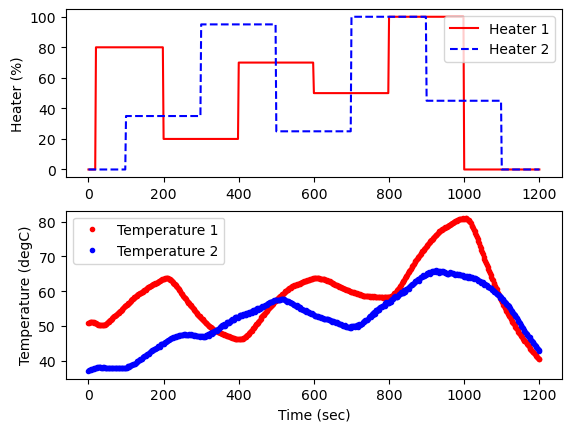

In [1]:
import numpy as np
import pandas as pd
import tclab
import time
import matplotlib.pyplot as plt
%matplotlib inline

# Stufentestdaten auf dem Arduino erzeugen
filename = '12-tclab.csv'

# Heizer-Stufen
Q1d = np.zeros(601)
Q1d[10:100] = 80
Q1d[100:200] = 20
Q1d[200:300] = 70
Q1d[300:400] = 50
Q1d[400:500] = 100
Q1d[500:] = 0

Q2d = np.zeros(601)
Q2d[50:150] = 35
Q2d[150:250] = 95
Q2d[250:350] = 25
Q2d[350:450] = 100
Q2d[450:550] = 45
Q2d[550:] = 0

# Arduino verbinden
a = tclab.TCLab()
fid = open(filename,'w')
fid.write('Time,Q1,Q2,T1,T2\n')
fid.close()

# Stufentest ausführen (20 Min.)
for i in range(601):
    # Heizwerte einstellen
    a.Q1(Q1d[i])
    a.Q2(Q2d[i])
    print('Time: ' + str(2*i) + \
          ' Q1: ' + str(Q1d[i]) + \
          ' Q2: ' + str(Q2d[i]) + \
          ' T1: ' + str(a.T1)   + \
          ' T2: ' + str(a.T2))
    # 2 Sekunden warten
    time.sleep(2)
    fid = open(filename,'a')
    fid.write(str(2*i)+','+str(Q1d[i])+','+str(Q2d[i])+',' \
              +str(a.T1)+','+str(a.T2)+'\n')
    fid.close()
# Verbindung von Arduino trennen
a.close()

# Daten auslesen
data = pd.read_csv(filename)

# Messdaten plotten
plt.figure()
plt.subplot(2,1,1)
plt.plot(data['Time'],data['Q1'],'r-',label='Heater 1')
plt.plot(data['Time'],data['Q2'],'b--',label='Heater 2')
plt.ylabel('Heater (%)')
plt.legend(loc='best')
plt.subplot(2,1,2)
plt.plot(data['Time'],data['T1'],'r.',label='Temperature 1')
plt.plot(data['Time'],data['T2'],'b.',label='Temperature 2')
plt.ylabel('Temperature (degC)')
plt.legend(loc='best')
plt.xlabel('Time (sec)')
plt.savefig('12-tclab.png')

plt.show()

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Modellprädiktive Regelung mit Zeitreihenmodell

**Modellprädiktive Regelung mit Zeitreihenmodell**

Führe die folgende Anwendung mit angeschlossenem TCLab aus. Sie nutzt die oben erstellten Stufentestdaten, um ein Zeitreihenmodell zu erzeugen. Anschließend verwendet die Anwendung dieses Modell, um eine Model Predictive Control (MPC) aufzubauen, die die Heizer so optimiert, dass Zieltemperaturen erreicht werden. Während der MPC läuft, puste auf die Heizer, um eine Störung zu verursachen. Beobachte, wie sich das vorhergesagte Heizerprofil ändert, sobald die Störung wirkt.

<video width="500" height="350" controls src="https://apmonitor.com/do/uploads/Main/tclab_arx_mpc.mp4" />

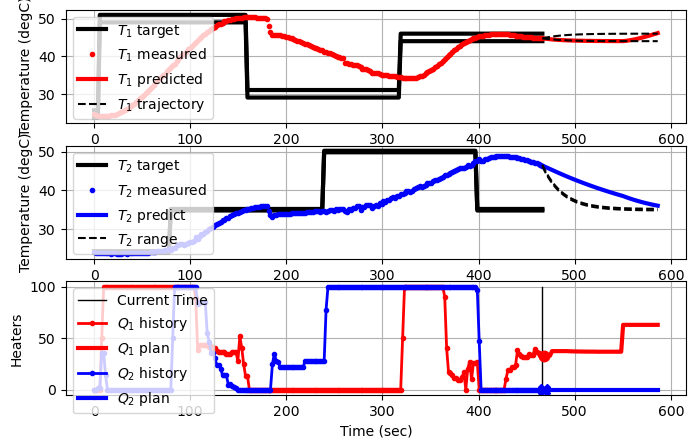

 ----------------------------------------------------------------
 APMonitor, Version 1.0.3
 APMonitor Optimization Suite
 ----------------------------------------------------------------
 
 
 --------- APM Model Size ------------
 Each time step contains
   Objects      :  1
   Constants    :  0
   Variables    :  4
   Intermediates:  0
   Connections  :  4
   Equations    :  0
   Residuals    :  0
 
 Number of state variables:    2280
 Number of total equations: -  2160
 Number of slack variables: -  0
 ---------------------------------------
 Degrees of freedom       :    120
 
 **********************************************
 Dynamic Control with Interior Point Solver
 **********************************************
  
  
 Info: Exact Hessian

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
       

In [7]:
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
import json
# Gekko-Paket installieren mit:
#   pip install gekko
from gekko import GEKKO
# tclab-Paket installieren mit:
#   pip install tclab
from tclab import TCLab

# Prüfen, ob die Sitzung eine IPython-Session ist
try:
    from IPython import get_ipython
    from IPython.display import display,clear_output
    get_ipython().run_line_magic('matplotlib', 'inline')
    ipython = True
    print('IPython Notebook')
except:
    ipython = False
    print('Not IPython Notebook')

# Arduino verbinden
a = TCLab()

# Endzeit
tf = 10 # Min.
# Anzahl Datenpunkte (alle zwei Sekunden)
n = tf * 30 + 1

# Prozent Heizer (0-100%)
Q1s = np.zeros(n)
Q2s = np.zeros(n)

# Temperaturen (degC)
T1m = a.T1 * np.ones(n)
T2m = a.T2 * np.ones(n)
# Temperatur-Sollwerte
T1sp = T1m[0] * np.ones(n)
T2sp = T2m[0] * np.ones(n)

# Heizer-Sollwertsprünge etwa alle 150 s
T1sp[3:] = 50.0
T2sp[40:] = 35.0
T1sp[80:] = 30.0
T2sp[120:] = 50.0
T1sp[160:] = 45.0
T2sp[200:] = 35.0
T1sp[240:] = 60.0

#########################################################
# Modell initialisieren
#########################################################
# Daten laden (20 min, dt=2 s) und in Spalten aufteilen
data = pd.read_csv('12-tclab.csv')
t = data['Time']
u = data[['Q1','Q2']]
y = data[['T1','T2']]

# Zeitreihenmodell erstellen
m = GEKKO(remote=False)

##################################################################
# Systemidentifikation
na = 2 # Ausgangskoeffizienten
nb = 2 # Eingangskoeffizienten
print('Identify model')
yp,p,K = m.sysid(t,u,y,na,nb,objf=10000,scale=False,diaglevel=1)

##################################################################
# sysid Ergebnisse darstellen
plt.figure()
plt.subplot(2,1,1)
plt.plot(t,u)
plt.legend([r'$Q_1$',r'$Q_2$'])
plt.ylabel('MVs')
plt.subplot(2,1,2)
plt.plot(t,y)
plt.plot(t,yp)
plt.legend([r'$T_{1meas}$',r'$T_{2meas}$',\
            r'$T_{1pred}$',r'$T_{2pred}$'])
plt.ylabel('CVs')
plt.xlabel('Time')
plt.savefig('sysid.png')
plt.show()

##################################################################
# ARX-Kontrollmodell erstellen
y = m.Array(m.CV,2)
u = m.Array(m.MV,2)
m.arx(p,y,u)

# CVs umbenennen
TC1 = y[0]
TC2 = y[1]

# MVs umbenennen
Q1 = u[0]
Q2 = u[1]

# Stationärzustand initialisieren
m.options.IMODE = 1
m.solve(disp=False)

# MPC einrichten
m.options.IMODE   = 6 # MPC
m.options.CV_TYPE = 1 # Zieltyp
m.options.NODES   = 2 # Kollokationsknoten
m.options.SOLVER  = 3 # IPOPT
m.time=np.linspace(0,120,61)

# Manipulierte Variablen
Q1.STATUS = 1  # manipuliert
Q1.FSTATUS = 0 # nicht gemessen
Q1.DMAX = 50.0
Q1.DCOST = 0.1
Q1.UPPER = 100.0
Q1.LOWER = 0.0

Q2.STATUS = 1  # manipuliert
Q2.FSTATUS = 0 # nicht gemessen
Q2.DMAX = 50.0
Q2.DCOST = 0.1
Q2.UPPER = 100.0
Q2.LOWER = 0.0

# Kontrollierte Variablen
TC1.STATUS = 1     # auf Sollwert regeln
TC1.FSTATUS = 1    # Messwert empfangen
TC1.TAU = 20       # Reaktionsgeschwindigkeit (Zeitkonstante)
TC1.TR_INIT = 2    # Referenztrajektorie
TC1.TR_OPEN = 0

TC2.STATUS = 1     # auf Sollwert regeln
TC2.FSTATUS = 1    # Messwert empfangen
TC2.TAU = 20       # Reaktionsgeschwindigkeit (Zeitkonstante)
TC2.TR_INIT = 2    # dead-band
TC2.TR_OPEN = 1

# Haupt-Loop
start_time = time.time()
prev_time = start_time
tm = np.zeros(n)

# Plot erstellen
if not ipython:
    plt.figure(figsize=(10,7))
    plt.ion()
    plt.show()

try:
    for i in range(1,n-1):
        # Wartezeit
        sleep_max = 2.0
        sleep = sleep_max - (time.time() - prev_time)
        if sleep>=0.01:
            time.sleep(sleep-0.01)
        else:
            time.sleep(0.01)

        # Zeit erfassen und Zeitänderung berechnen
        t = time.time()
        dt = t - prev_time
        prev_time = t
        tm[i] = t - start_time

        # Temperaturen in Celsius lesen
        T1m[i] = a.T1
        T2m[i] = a.T2

        # Messwerte eintragen
        TC1.MEAS = T1m[i]
        TC2.MEAS = T2m[i]

        # Sollwerte anpassen
        db1 = 1.0 # dead-band
        TC1.SPHI = T1sp[i] + db1
        TC1.SPLO = T1sp[i] - db1

        db2 = 0.2
        TC2.SPHI = T2sp[i] + db2
        TC2.SPLO = T2sp[i] - db2

        # Heizer mit MPC anpassen
        m.solve() 

        if m.options.APPSTATUS == 1:
            # neue Werte erhalten
            Q1s[i+1]  = Q1.NEWVAL
            Q2s[i+1]  = Q2.NEWVAL
            # zusätzliche Lösungsinformationen abrufen
            with open(m.path+'//results.json') as f:
                results = json.load(f)
        else:
            # Lösung gescheitert
            Q1s[i+1]  = 0.0
            Q2s[i+1]  = 0.0

        # Neue Heizwerte schreiben (0-100)
        a.Q1(Q1s[i])
        a.Q2(Q2s[i])

        # Plot
        # Plot
        if ipython:
            plt.figure(figsize=(8,5))
        else:
            plt.clf()
        ax=plt.subplot(3,1,1)
        ax.grid()
        plt.plot(tm[0:i+1],T1sp[0:i+1]+db1,'k-',\
                 label=r'$T_1$ target',linewidth=3)
        plt.plot(tm[0:i+1],T1sp[0:i+1]-db1,'k-',\
                 label=None,linewidth=3)
        plt.plot(tm[0:i+1],T1m[0:i+1],'r.',label=r'$T_1$ measured')
        plt.plot(tm[i]+m.time,results['v1.bcv'],'r-',\
                 label=r'$T_1$ predicted',linewidth=3)
        plt.plot(tm[i]+m.time,results['v1.tr_hi'],'k--',\
                 label=r'$T_1$ trajectory')
        plt.plot(tm[i]+m.time,results['v1.tr_lo'],'k--')
        plt.ylabel('Temperature (degC)')
        plt.legend(loc=2)
        ax=plt.subplot(3,1,2)
        ax.grid()        
        plt.plot(tm[0:i+1],T2sp[0:i+1]+db2,'k-',\
                 label=r'$T_2$ target',linewidth=3)
        plt.plot(tm[0:i+1],T2sp[0:i+1]-db2,'k-',\
                 label=None,linewidth=3)
        plt.plot(tm[0:i+1],T2m[0:i+1],'b.',label=r'$T_2$ measured')
        plt.plot(tm[i]+m.time,results['v2.bcv'],'b-',\
                 label=r'$T_2$ predict',linewidth=3)
        plt.plot(tm[i]+m.time,results['v2.tr_hi'],'k--',\
                 label=r'$T_2$ range')
        plt.plot(tm[i]+m.time,results['v2.tr_lo'],'k--')
        plt.ylabel('Temperature (degC)')
        plt.legend(loc=2)
        ax=plt.subplot(3,1,3)
        ax.grid()
        plt.plot([tm[i],tm[i]],[0,100],'k-',\
                 label='Current Time',linewidth=1)
        plt.plot(tm[0:i+1],Q1s[0:i+1],'r.-',\
                 label=r'$Q_1$ history',linewidth=2)
        plt.plot(tm[i]+m.time,Q1.value,'r-',\
                 label=r'$Q_1$ plan',linewidth=3)
        plt.plot(tm[0:i+1],Q2s[0:i+1],'b.-',\
                 label=r'$Q_2$ history',linewidth=2)
        plt.plot(tm[i]+m.time,Q2.value,'b-',
                 label=r'$Q_2$ plan',linewidth=3)
        plt.plot(tm[i]+m.time[1],Q1.value[1],color='red',\
                 marker='.',markersize=15)
        plt.plot(tm[i]+m.time[1],Q2.value[1],color='blue',\
                 marker='X',markersize=8)
        plt.ylabel('Heaters')
        plt.xlabel('Time (sec)')
        plt.legend(loc=2)
        if ipython:
            clear_output(wait=True)
            display(plt.gcf())
        else:
            plt.draw()
            plt.pause(0.05)

    # Heizer ausschalten und Verbindung beenden
    a.Q1(0)
    a.Q2(0)
    a.close()
    # Abbildung speichern
    plt.savefig('12-tclab_mpc.png')

# Dem Nutzer erlauben, den Loop mit Ctrl-C zu beenden          
except KeyboardInterrupt:
    # Heizer ausschalten und Verbindung beenden
    a.Q1(0)
    a.Q2(0)
    a.close()
    print('Shutting down')
    plt.savefig('12-tclab_mpc.png')

# Sicherstellen, dass die serielle Verbindung auch bei einem Fehler geschlossen wird
except:           
    # Arduino trennen
    a.Q1(0)
    a.Q2(0)
    a.close()
    print('Error: Shutting down')
    plt.savefig('12-tclab_mpc.png')
    raise

### Vorschau: Training eines GRU-Netzes für die Zeitreihenvorhersage des TCLab

In dieser Zelle wird ein rekurrentes neuronales Netz vom Typ **GRU** (*Gated Recurrent Unit*) mit aufgezeichneten Daten des TCLab trainiert.

Als Eingänge werden über ein Zeitfenster die vergangenen Werte von

- $Q_1$: Heizleistung Heizer 1
- $Q_2$: Heizleistung Heizer 2
- $T_1$: Temperatur Sensor 1
- $T_2$: Temperatur Sensor 2

verwendet.

Das Netz lernt daraus, die nächsten Temperaturen $T_{1,k+1}$ und $T_{2,k+1}$ vorherzusagen.

Als Standard-Fehlermaß für das Training wird die **mittlere quadratische Abweichung** verwendet:

$$
\mathcal{L}_{\mathrm{MSE}}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(y_i-\hat{y}_i\right)^2
$$

Zusätzlich wird nach dem Training die **RMSE** berechnet. Diese ist anschaulich, weil sie direkt in der Einheit der Temperatur, also in $^\circ\mathrm{C}$, angegeben werden kann.

Die trainierten Artefakte werden gespeichert, damit die spätere Live-Regelungszelle unabhängig vom Training ausgeführt werden kann.

In [21]:
# Falls nötig:
#!pip install tensorflow scikit-learn joblib

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

C:\Users\eichhorn\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.1118 - mae: 0.2960 - val_loss: 0.2339 - val_mae: 0.4285
Epoch 2/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0272 - mae: 0.1342 - val_loss: 0.0994 - val_mae: 0.2830
Epoch 3/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0424 - mae: 0.1602 - val_loss: 0.0780 - val_mae: 0.2509
Epoch 4/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0377 - mae: 0.1486 - val_loss: 0.0768 - val_mae: 0.2501
Epoch 5/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0273 - mae: 0.1281 - val_loss: 0.0644 - val_mae: 0.2289
Epoch 6/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0255 - mae: 0.1215 - val_loss: 0.0539 - val_mae: 0.2088
Epoch 7/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0214 - mae: 0.1085 - val_loss: 0.0467 - val_mae: 0.1924
Epoch 8/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0173 - mae: 0.0949 - val_loss: 0.0403 - val_mae: 0.1769
Epoch 9/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - lo

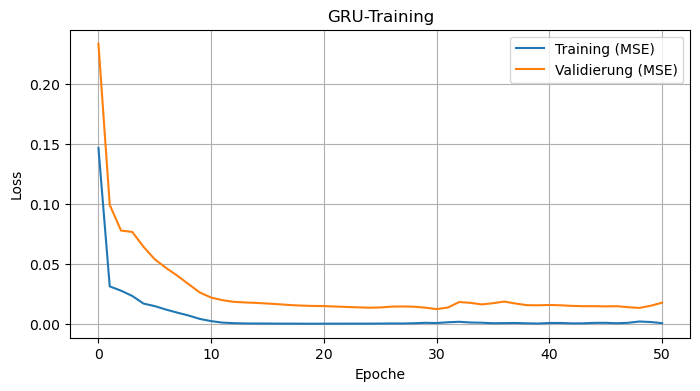

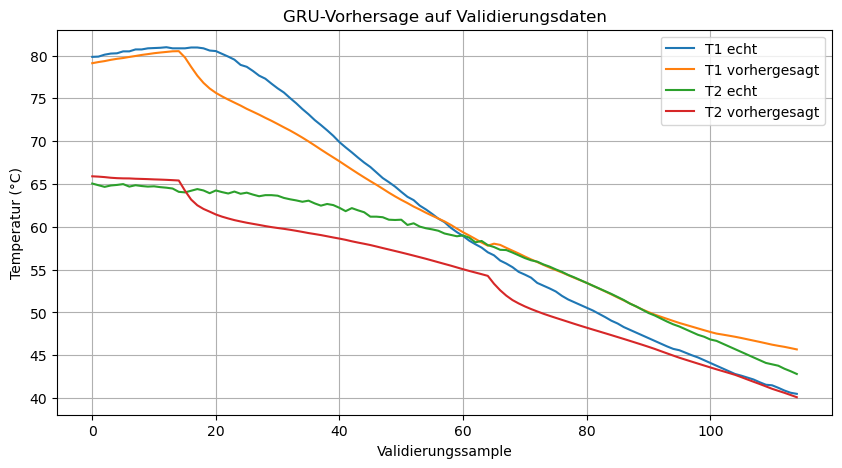

Modell gespeichert in: gru_tclab_model.keras
x-Scaler gespeichert in: gru_x_scaler.gz
y-Scaler gespeichert in: gru_y_scaler.gz
Metadaten gespeichert in: gru_tclab_meta.json


In [31]:
# ------------------------------------------------------------
# Einstellungen
# ------------------------------------------------------------
SEED = 7
WINDOW = 30              # 20 Schritte Historie = 40 s bei dt=2 s
EPOCHS = 250
BATCH_SIZE = 32

MODEL_FILE = "gru_tclab_model.keras"
XSCALER_FILE = "gru_x_scaler.gz"
YSCALER_FILE = "gru_y_scaler.gz"
META_FILE = "gru_tclab_meta.json"

DATA_CANDIDATES = [Path("12-TCLab.csv"), Path("12-tclab.csv")]

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Datei finden
# ------------------------------------------------------------
data_file = None
for candidate in DATA_CANDIDATES:
    if candidate.exists():
        data_file = candidate
        break

if data_file is None:
    raise FileNotFoundError(
        "Keine Datendatei gefunden. Erwartet: 12-TCLab.csv oder 12-tclab.csv"
    )

# ------------------------------------------------------------
# Daten laden
# ------------------------------------------------------------
data = pd.read_csv(data_file)

required_cols = ["Time", "Q1", "Q2", "T1", "T2"]
missing = [c for c in required_cols if c not in data.columns]
if missing:
    raise ValueError(f"Fehlende Spalten: {missing}")

raw_features = data[["Q1", "Q2", "T1", "T2"]].values.astype(np.float32)
raw_targets = data[["T1", "T2"]].values.astype(np.float32)

# ------------------------------------------------------------
# Sequenzen bilden
# Eingabe: letzte WINDOW Werte von [Q1,Q2,T1,T2]
# Ziel:    nächster Wert [T1,T2]
# ------------------------------------------------------------
X_raw, y_raw = [], []

for end_idx in range(WINDOW - 1, len(data) - 1):
    seq = raw_features[end_idx - WINDOW + 1:end_idx + 1]
    nxt = raw_targets[end_idx + 1]
    X_raw.append(seq)
    y_raw.append(nxt)

X_raw = np.asarray(X_raw, dtype=np.float32)
y_raw = np.asarray(y_raw, dtype=np.float32)

if len(X_raw) < 20:
    raise ValueError("Zu wenige Datenpunkte für das Training des GRU-Modells.")

# Zeitliche Trennung: erstes Stück Training, letzter Teil Validierung
split_idx = int(0.8 * len(X_raw))
X_train_raw, X_val_raw = X_raw[:split_idx], X_raw[split_idx:]
y_train_raw, y_val_raw = y_raw[:split_idx], y_raw[split_idx:]

# ------------------------------------------------------------
# Skalierung
# ------------------------------------------------------------
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

x_scaler.fit(X_train_raw.reshape(-1, X_train_raw.shape[-1]))
y_scaler.fit(y_train_raw)

def scale_sequences(x_raw):
    x_scaled = x_scaler.transform(x_raw.reshape(-1, x_raw.shape[-1]))
    return x_scaled.reshape(x_raw.shape)

X_train = scale_sequences(X_train_raw)
X_val = scale_sequences(X_val_raw)
y_train = y_scaler.transform(y_train_raw)
y_val = y_scaler.transform(y_val_raw)

# ------------------------------------------------------------
# GRU-Modell
# ------------------------------------------------------------
model = Sequential([
    GRU(48, input_shape=(WINDOW, 4)),
    Dense(32, activation="relu"),
    Dense(2)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=False,
    verbose=1,
    callbacks=callbacks
)

# ------------------------------------------------------------
# Auswertung
# ------------------------------------------------------------
train_pred = y_scaler.inverse_transform(model.predict(X_train, verbose=0))
val_pred = y_scaler.inverse_transform(model.predict(X_val, verbose=0))

train_rmse_t1 = np.sqrt(mean_squared_error(y_train_raw[:, 0], train_pred[:, 0]))
train_rmse_t2 = np.sqrt(mean_squared_error(y_train_raw[:, 1], train_pred[:, 1]))
val_rmse_t1 = np.sqrt(mean_squared_error(y_val_raw[:, 0], val_pred[:, 0]))
val_rmse_t2 = np.sqrt(mean_squared_error(y_val_raw[:, 1], val_pred[:, 1]))

print(f"Train-RMSE T1: {train_rmse_t1:.3f} °C")
print(f"Train-RMSE T2: {train_rmse_t2:.3f} °C")
print(f"Val-RMSE   T1: {val_rmse_t1:.3f} °C")
print(f"Val-RMSE   T2: {val_rmse_t2:.3f} °C")

# ------------------------------------------------------------
# Plot Trainingsverlauf
# ------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training (MSE)")
plt.plot(history.history["val_loss"], label="Validierung (MSE)")
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.title("GRU-Training")
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# Plot Vorhersage auf Validierungsdaten
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(y_val_raw[:, 0], label="T1 echt")
plt.plot(val_pred[:, 0], label="T1 vorhergesagt")
plt.plot(y_val_raw[:, 1], label="T2 echt")
plt.plot(val_pred[:, 1], label="T2 vorhergesagt")
plt.xlabel("Validierungssample")
plt.ylabel("Temperatur (°C)")
plt.title("GRU-Vorhersage auf Validierungsdaten")
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# Artefakte speichern
# ------------------------------------------------------------
model.save(MODEL_FILE)
joblib.dump(x_scaler, XSCALER_FILE)
joblib.dump(y_scaler, YSCALER_FILE)

meta = {
    "window": WINDOW,
    "feature_order": ["Q1", "Q2", "T1", "T2"],
    "target_order": ["T1", "T2"]
}
with open(META_FILE, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print(f"Modell gespeichert in: {MODEL_FILE}")
print(f"x-Scaler gespeichert in: {XSCALER_FILE}")
print(f"y-Scaler gespeichert in: {YSCALER_FILE}")
print(f"Metadaten gespeichert in: {META_FILE}")

### Live-Regelung des TCLab mit einem trainierten GRU-Vorhersagemodell - WIP

In dieser Zelle wird das zuvor trainierte GRU-Modell geladen und als datengetriebenes Vorhersagemodell für eine vereinfachte prädiktive Regelung verwendet.

Das neuronale Netz sagt aus den letzten Messwerten die zukünftigen Temperaturen voraus. Für mehrere mögliche Heizereinstellungen $(Q_1,Q_2)$ wird die Zukunft über einen Vorhersagehorizont abgeschätzt. Anschließend wird diejenige Stellgröße gewählt, die die Sollwerte am besten trifft.

Die Bewertungsfunktion kombiniert Sollwertfehler und Stellgrößenaufwand:

$$
J
=
\sum_{h=1}^{N_p}
\left[
w_1 \left(T_{1,h}^{\mathrm{pred}} - T_{1,h}^{\mathrm{sp}}\right)^2
+
w_2 \left(T_{2,h}^{\mathrm{pred}} - T_{2,h}^{\mathrm{sp}}\right)^2
\right]
+
\lambda_{\Delta u}
\left[
(Q_1-Q_{1,\mathrm{alt}})^2 + (Q_2-Q_{2,\mathrm{alt}})^2
\right]
+
\lambda_u
\left(Q_1^2 + Q_2^2\right)
$$

Dabei ist:

- $N_p$: Vorhersagehorizont
- $T_{1,h}^{\mathrm{pred}}, T_{2,h}^{\mathrm{pred}}$: vom GRU vorhergesagte Temperaturen
- $T_{1,h}^{\mathrm{sp}}, T_{2,h}^{\mathrm{sp}}$: Solltemperaturen
- $Q_1, Q_2$: gewählte Heizleistungen

Die Sollwerte sind identisch zum vorherigen MPC-Beispiel, damit beide Ansätze direkt verglichen werden können.

**Wichtig:**  
Diese Zelle setzt voraus, dass die Trainingszelle vorher ausgeführt wurde und die Dateien

- `gru_tclab_model.keras`
- `gru_x_scaler.gz`
- `gru_y_scaler.gz`
- `gru_tclab_meta.json`

bereits vorliegen.

TCLab version 1.0.0
Arduino Leonardo connected on port COM7 at 115200 baud.
TCLab Firmware 2.0.1 Arduino Leonardo/Micro.


<Figure size 1000x700 with 0 Axes>

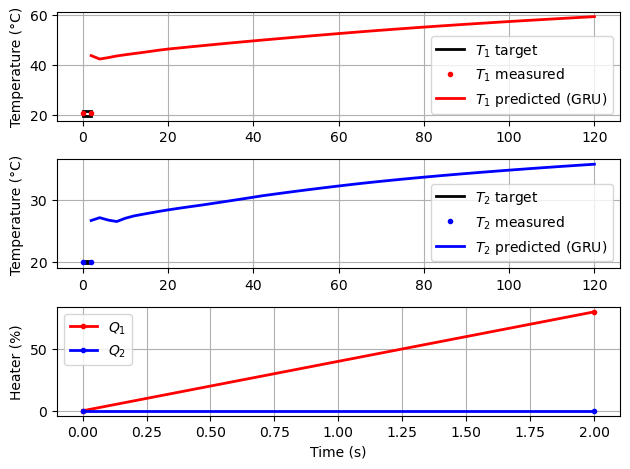

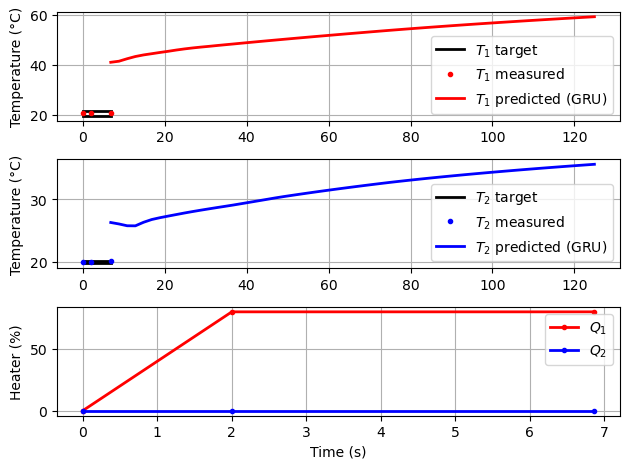

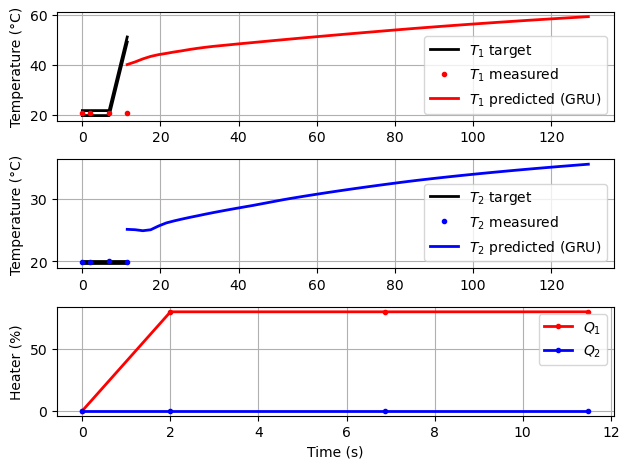

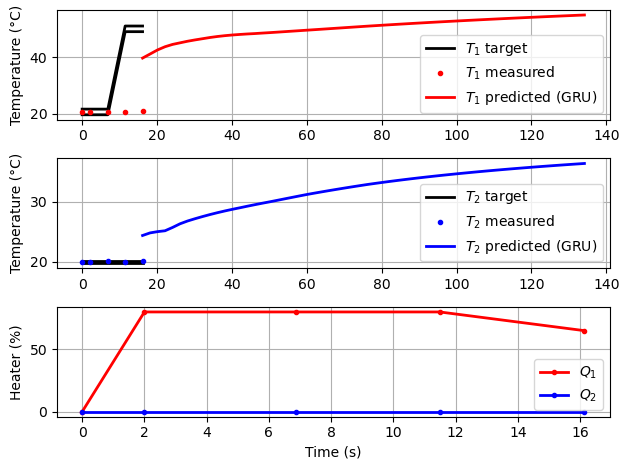

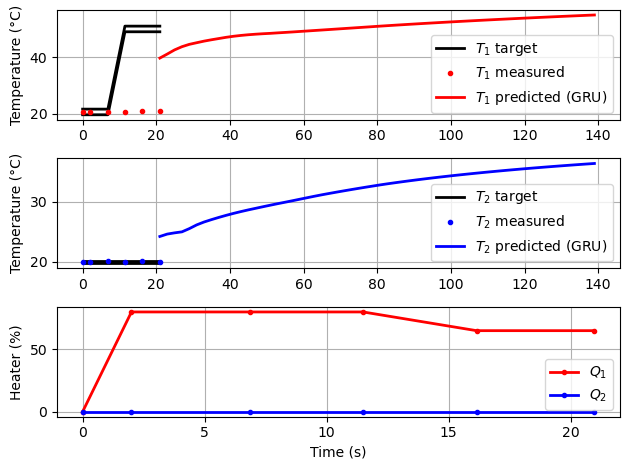

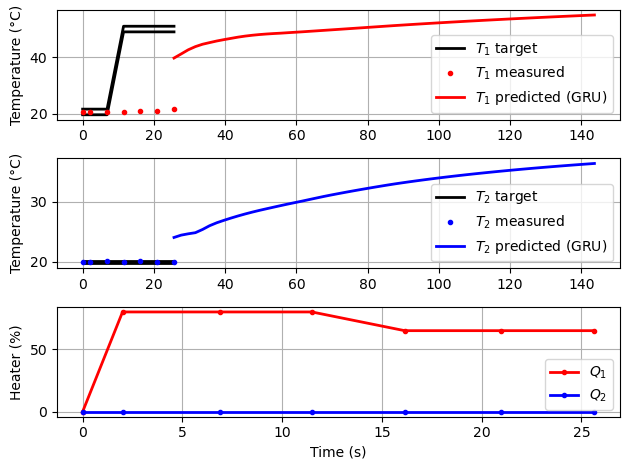

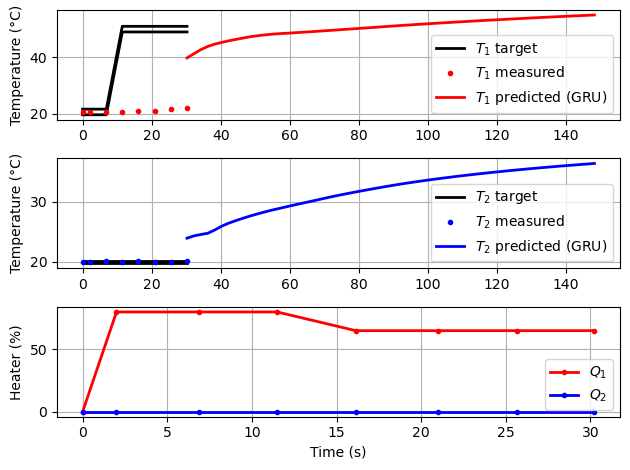

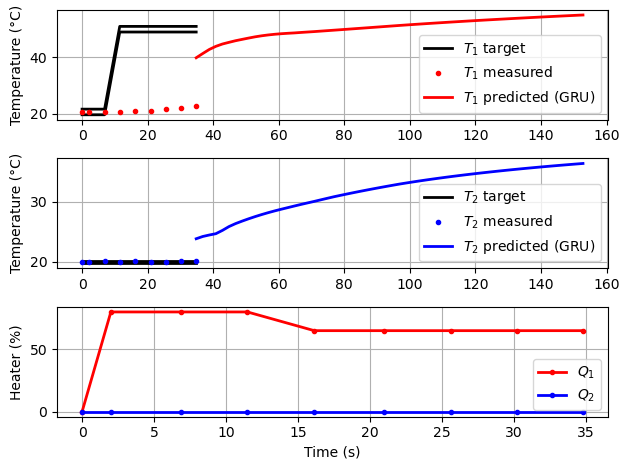

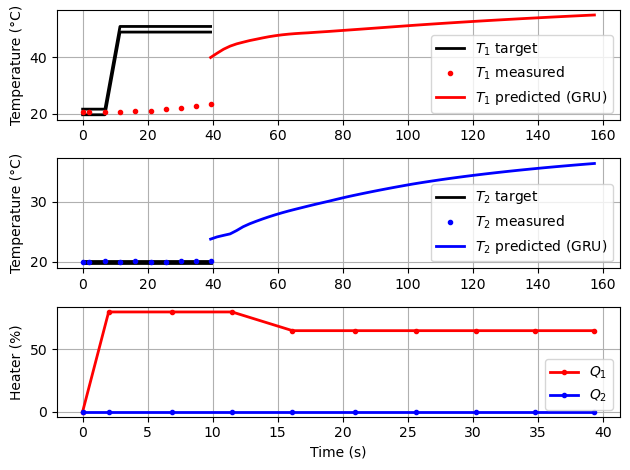

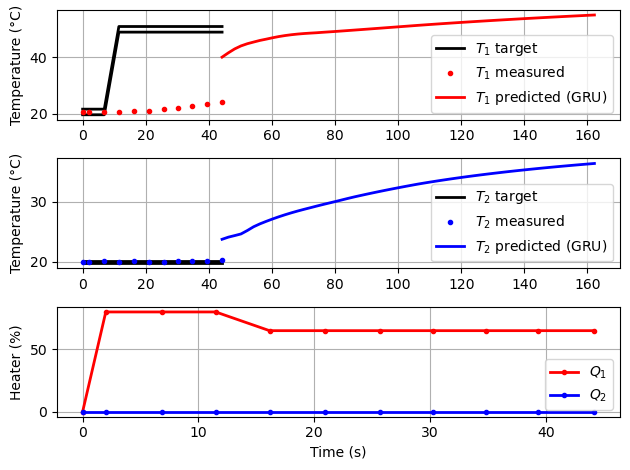

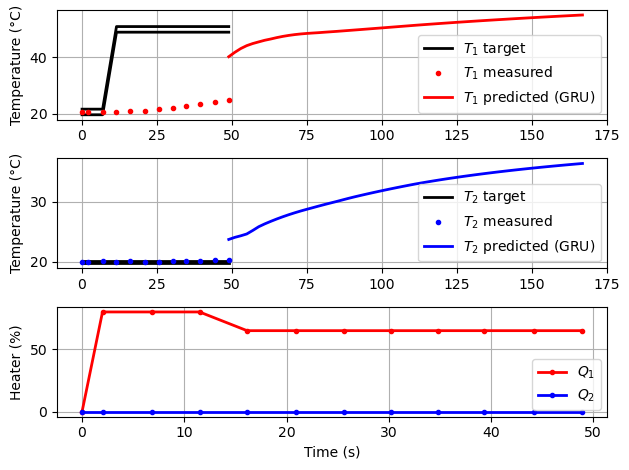

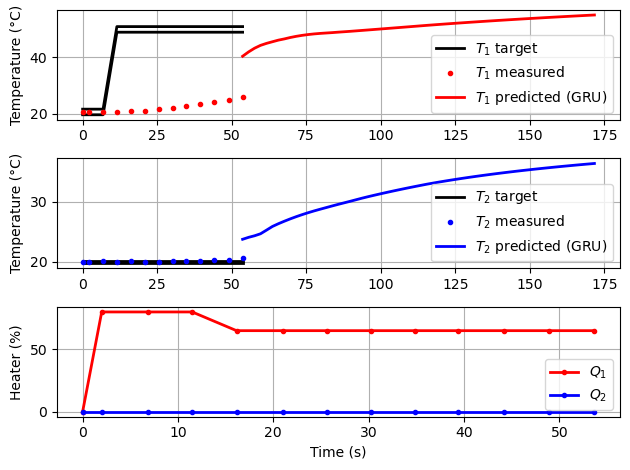

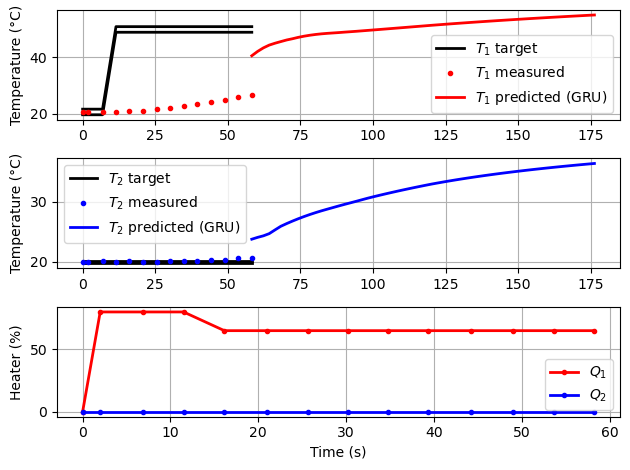

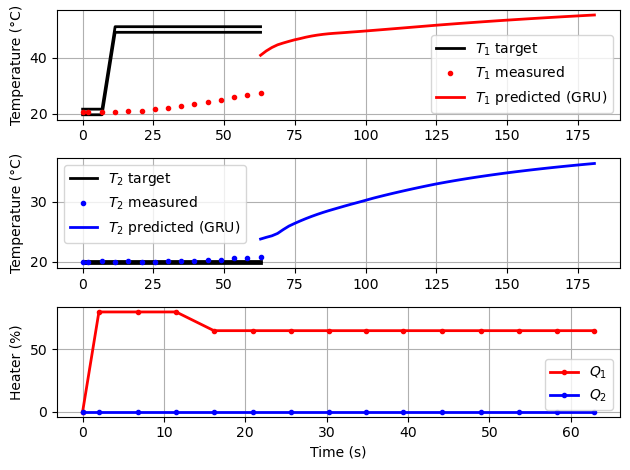

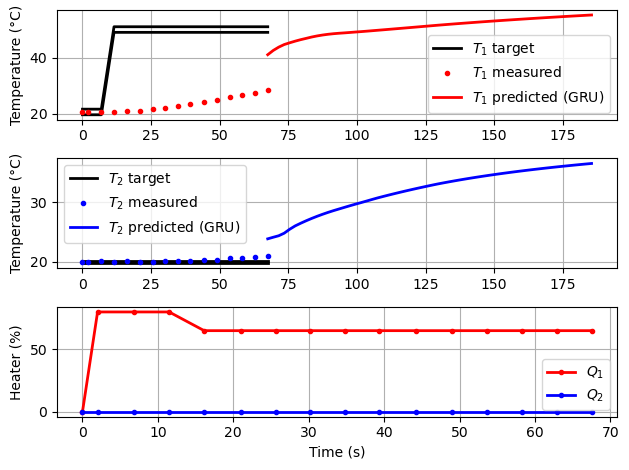

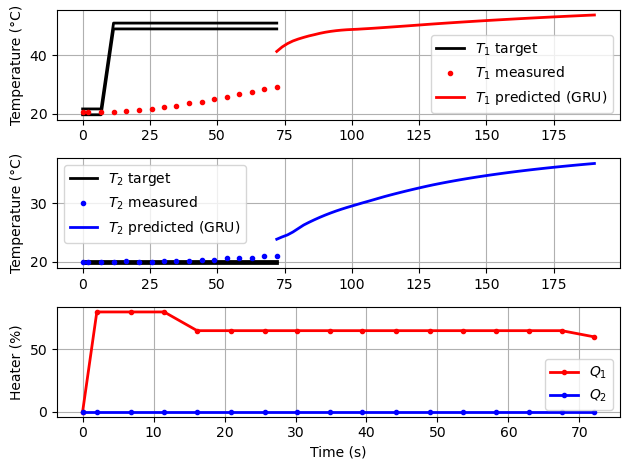

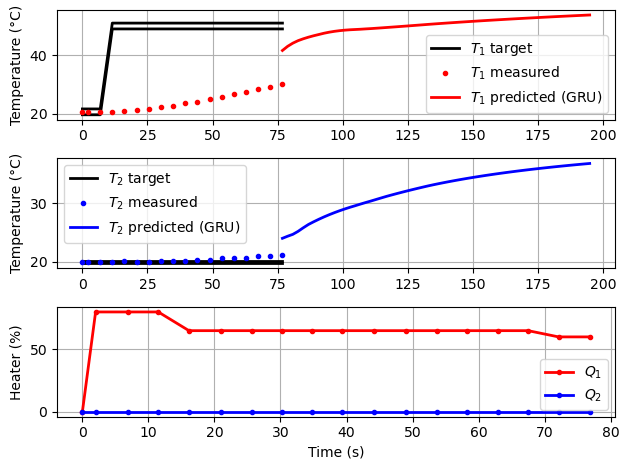

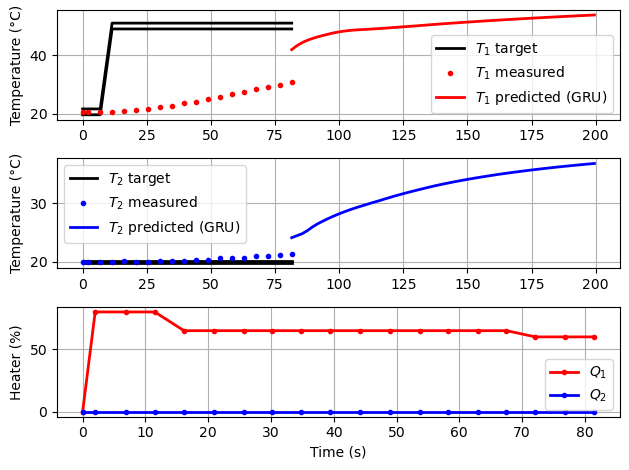

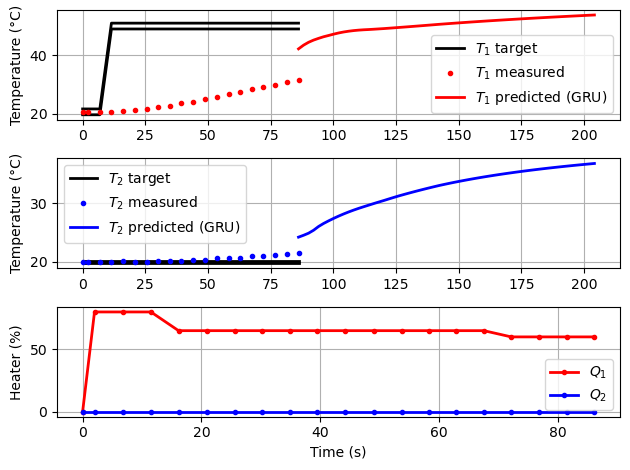

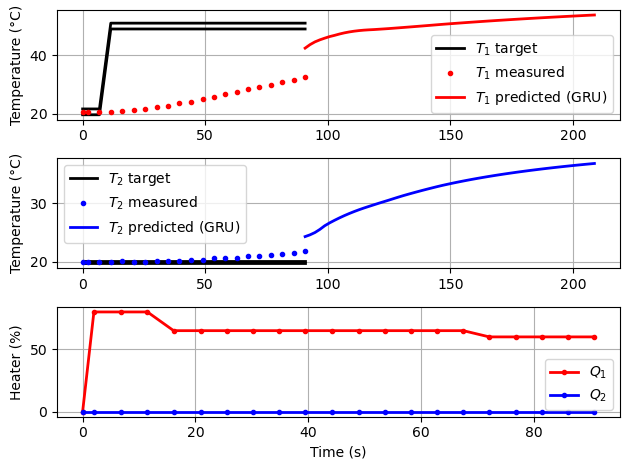

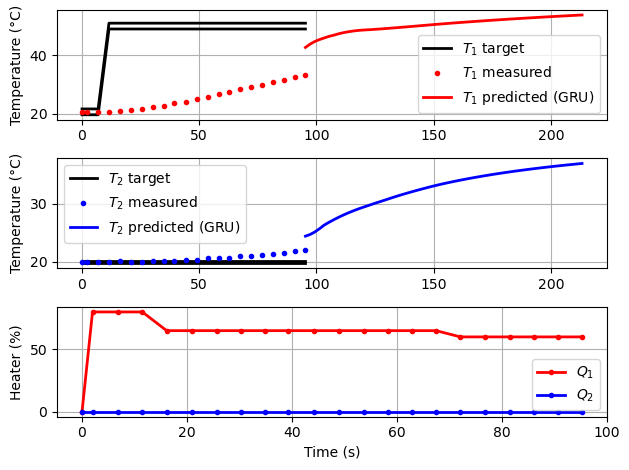

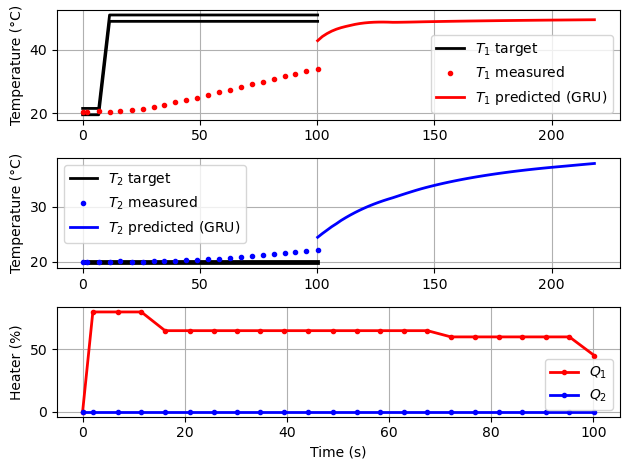

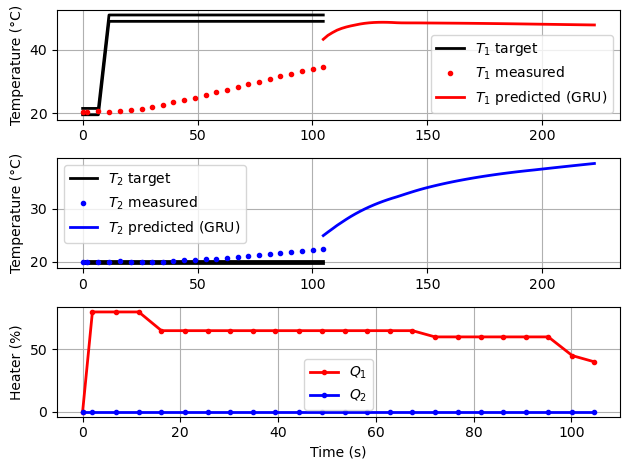

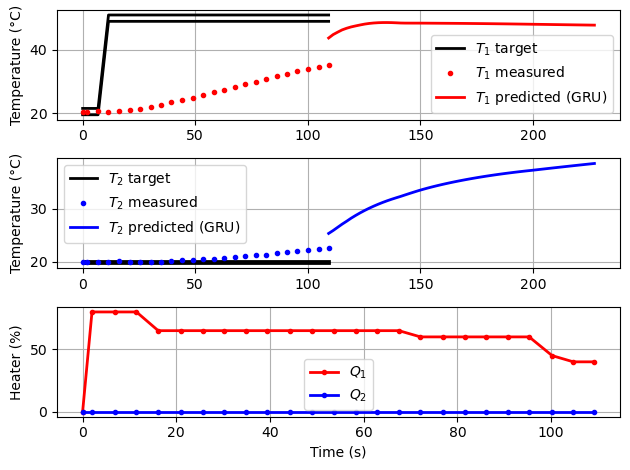

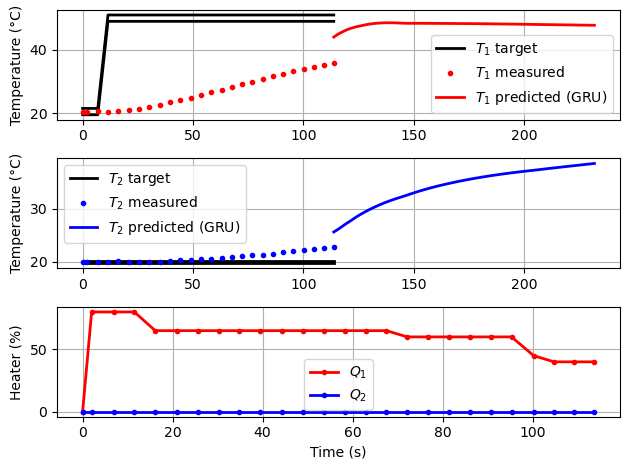

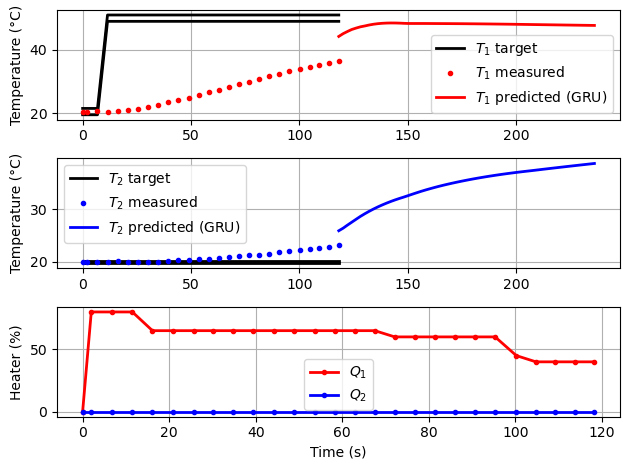

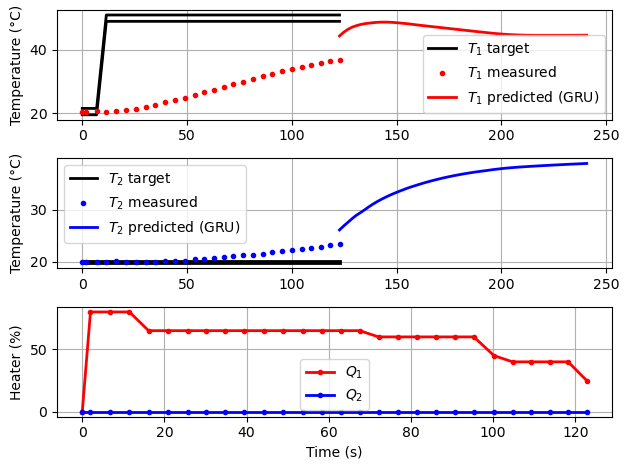

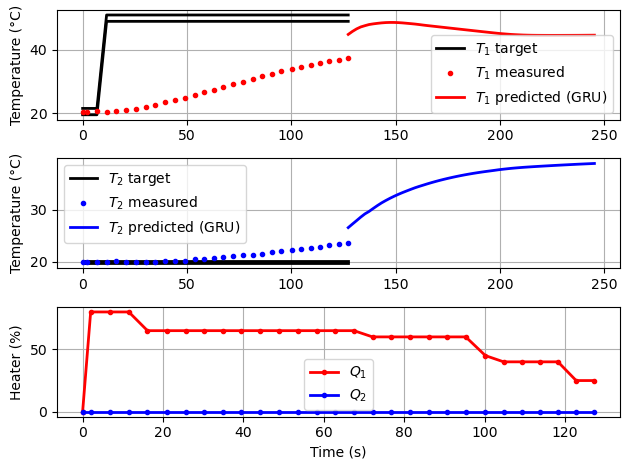

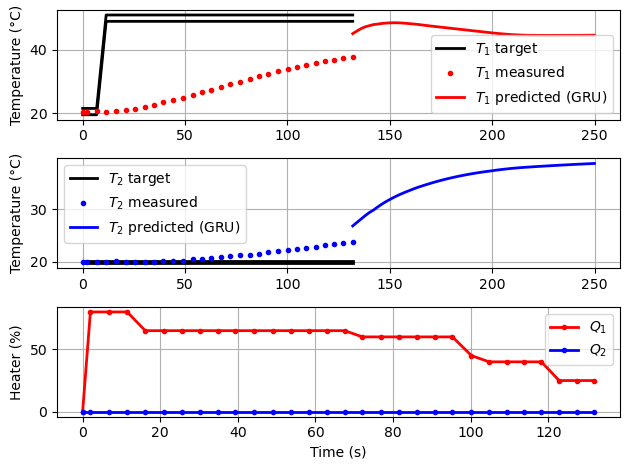

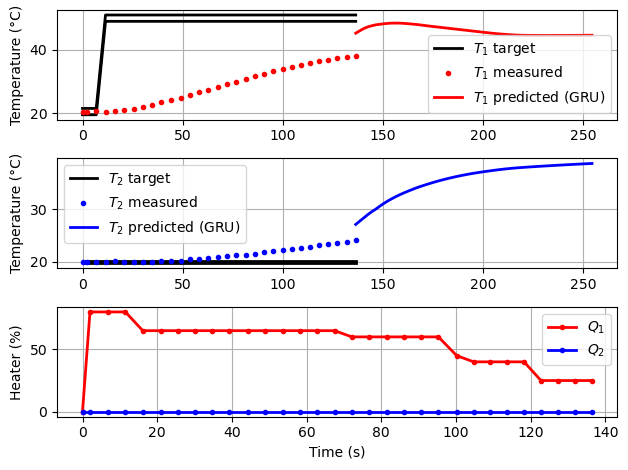

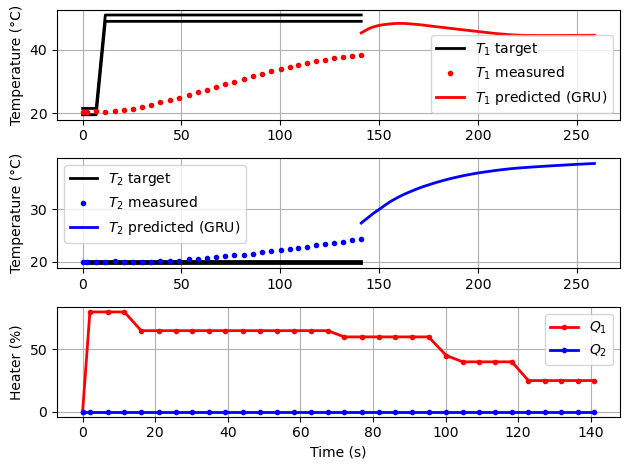

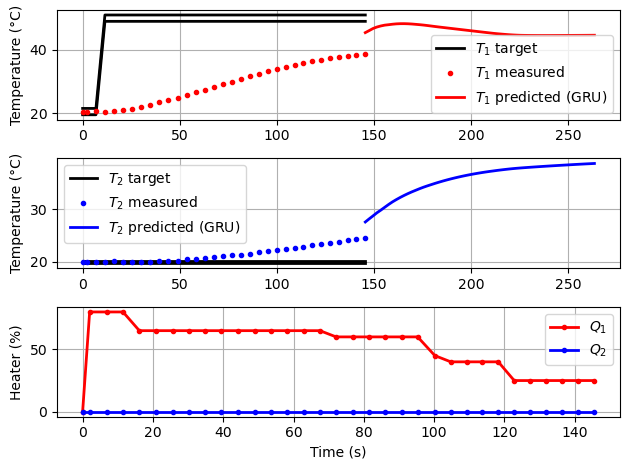

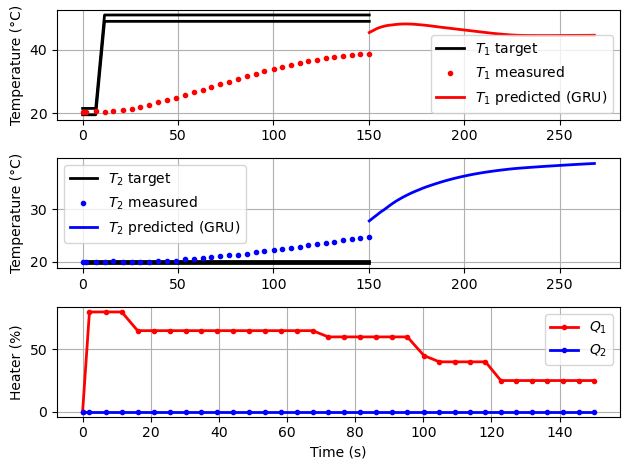

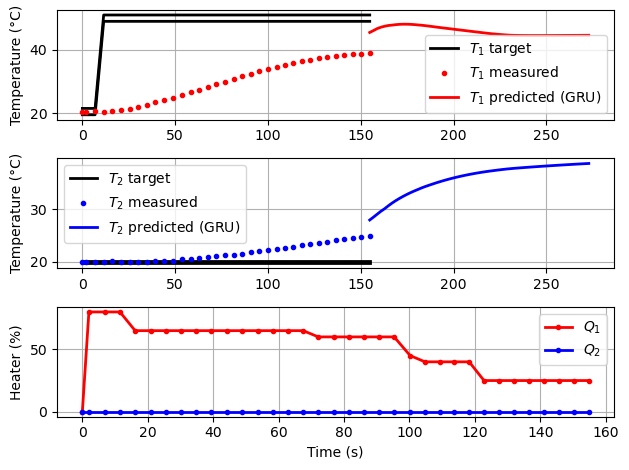

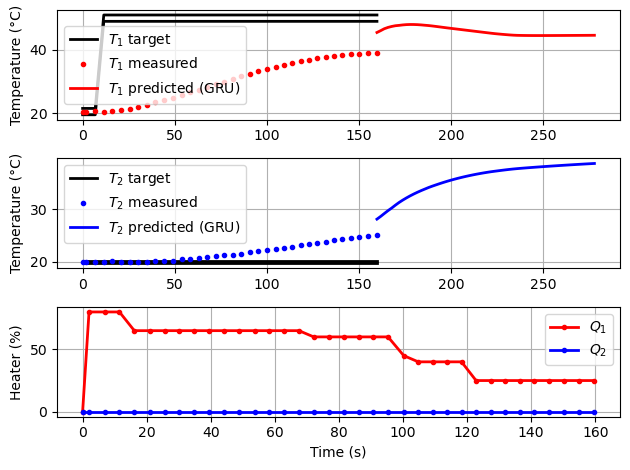

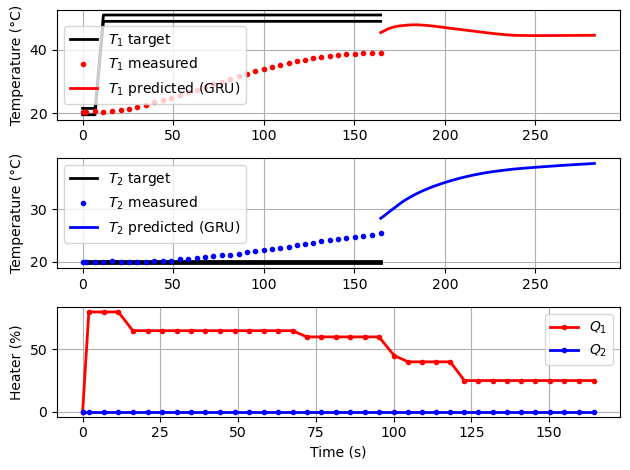

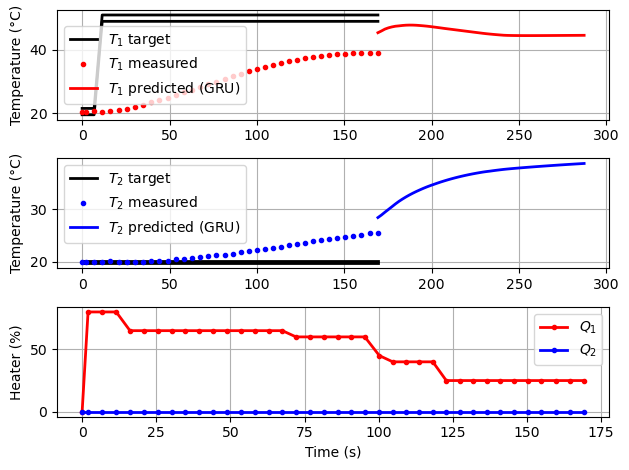

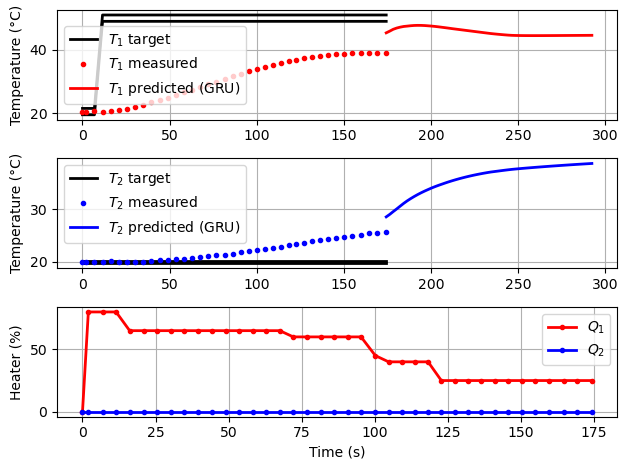

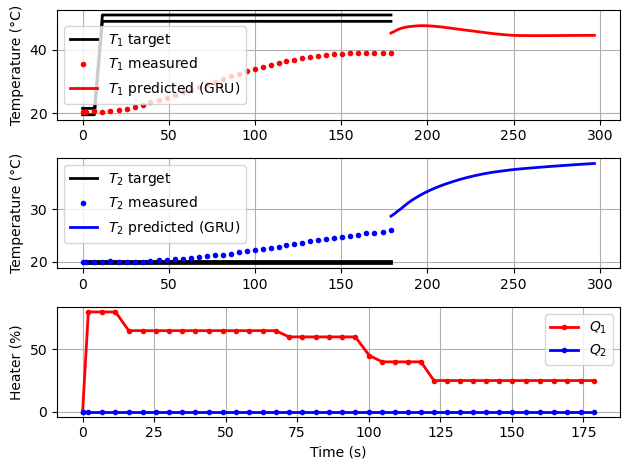

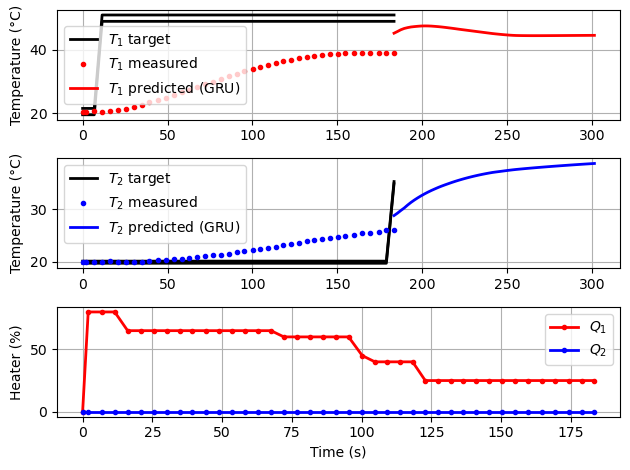

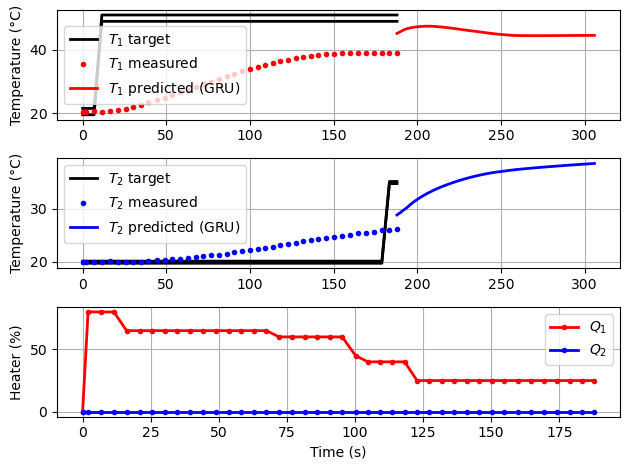

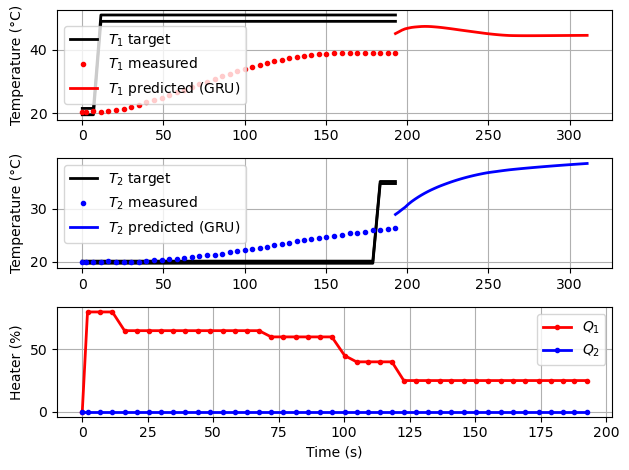

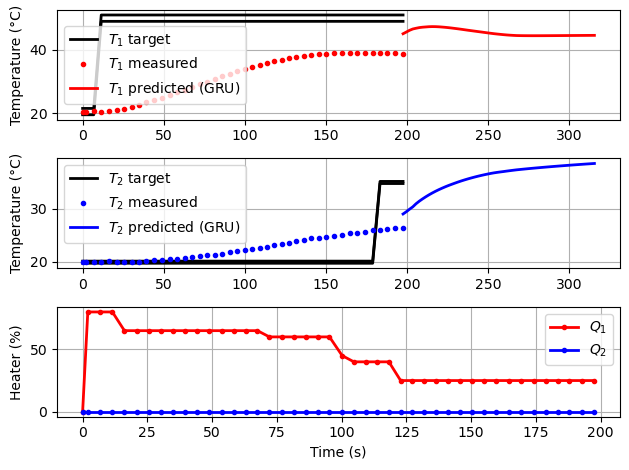

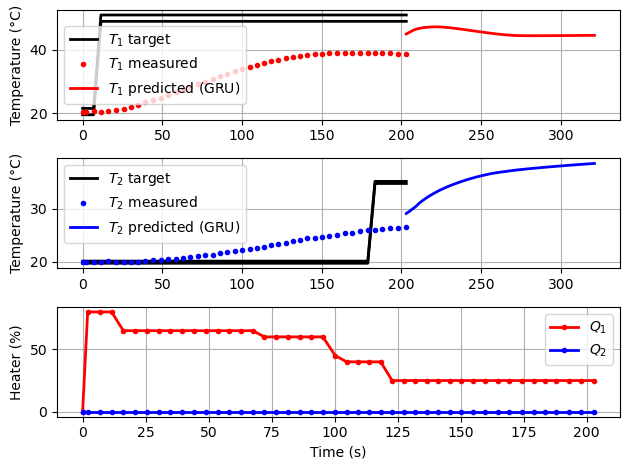

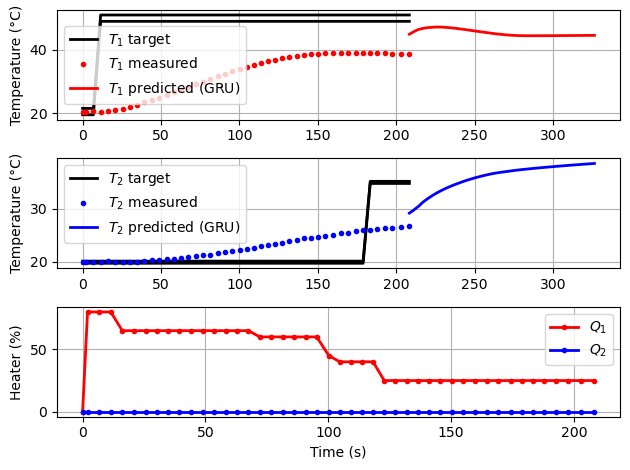

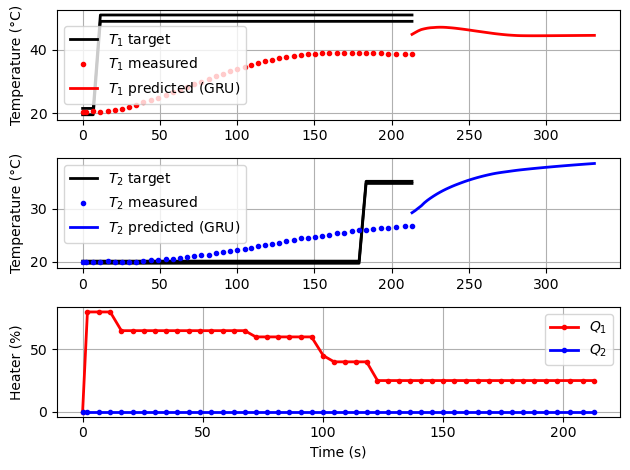

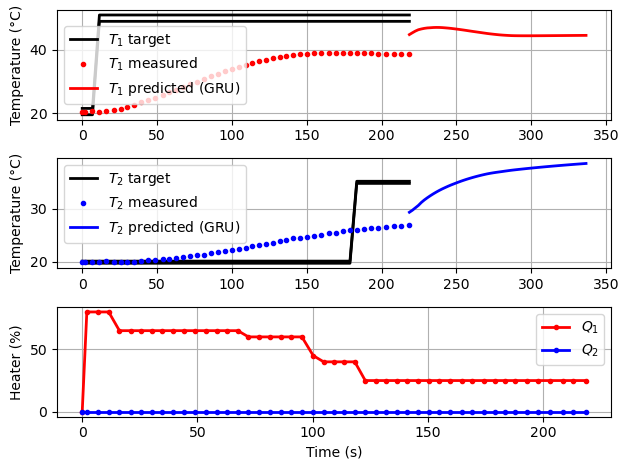

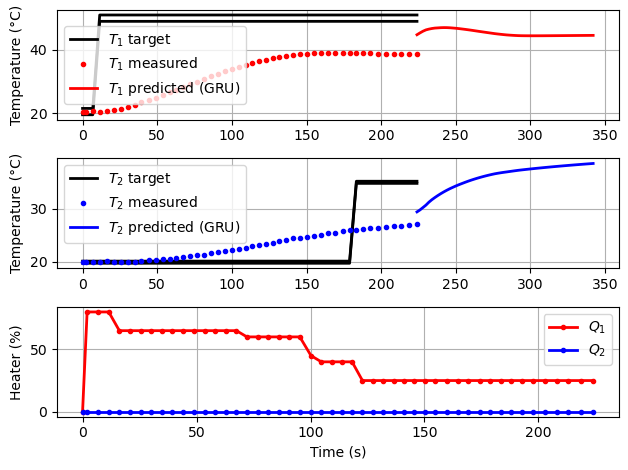

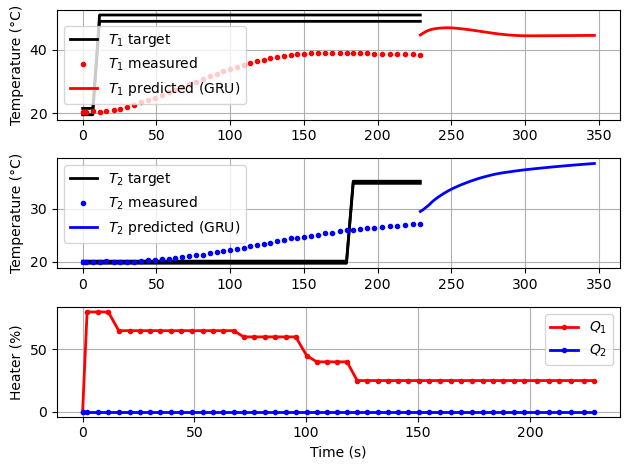

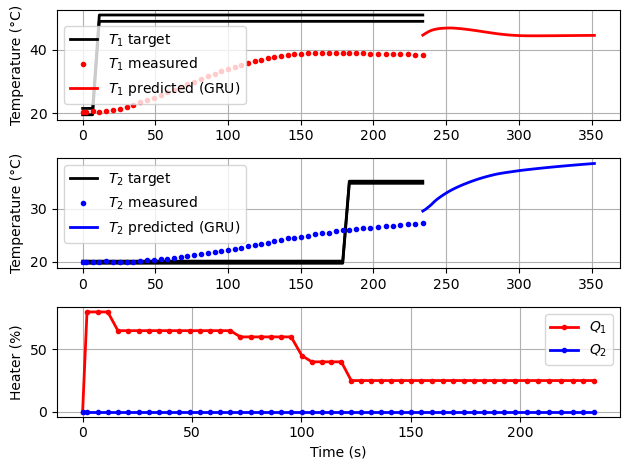

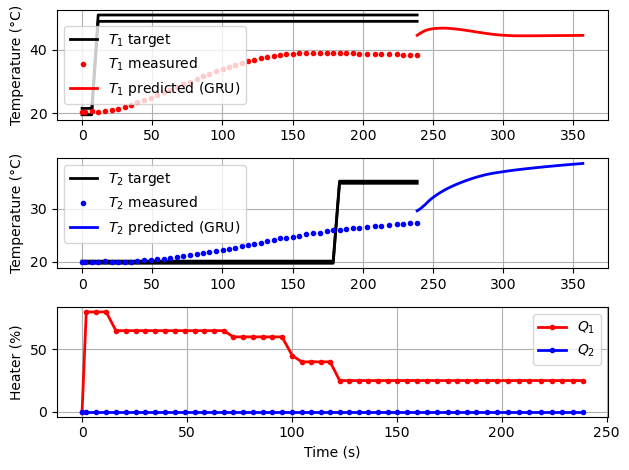

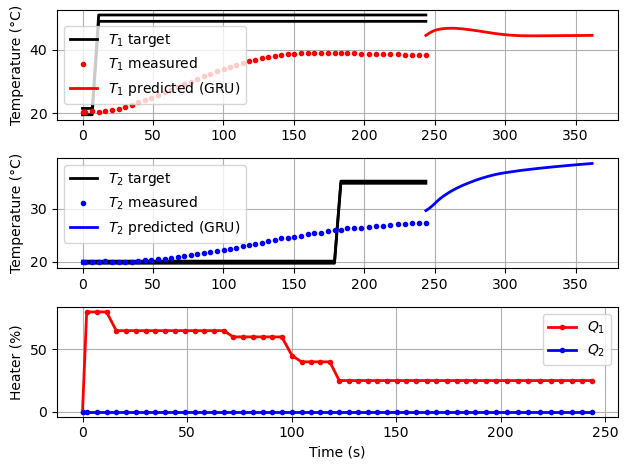

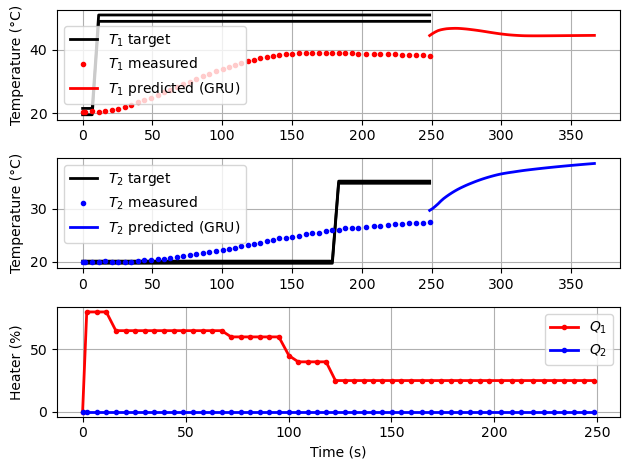

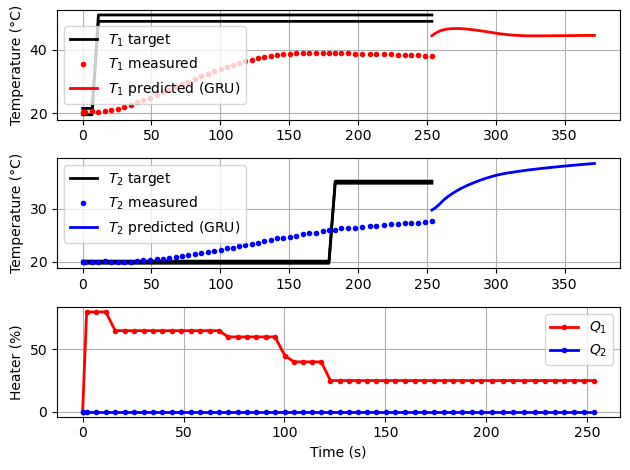

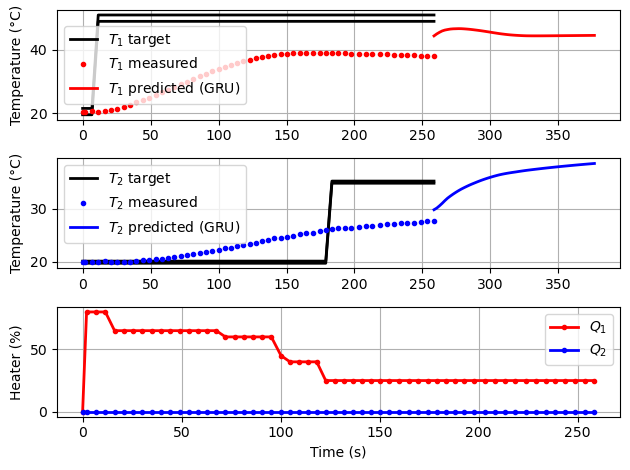

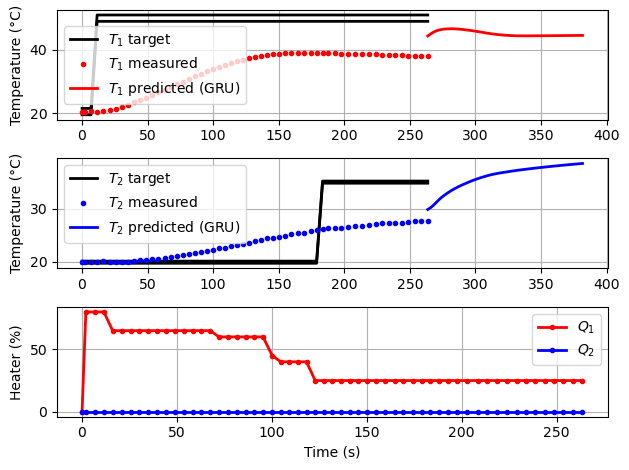

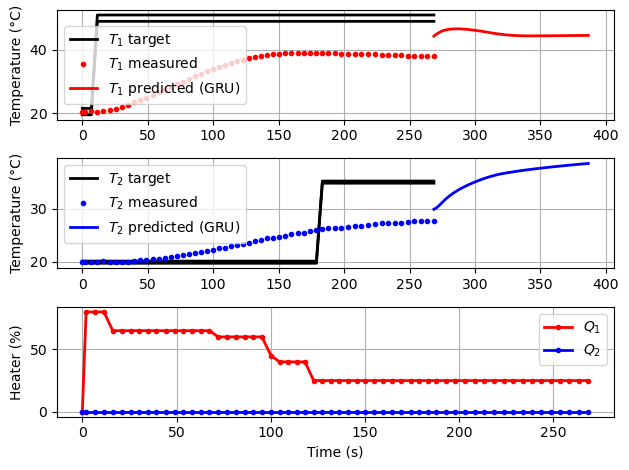

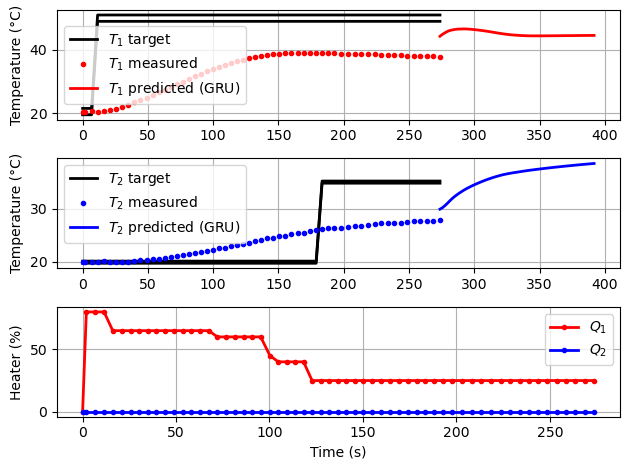

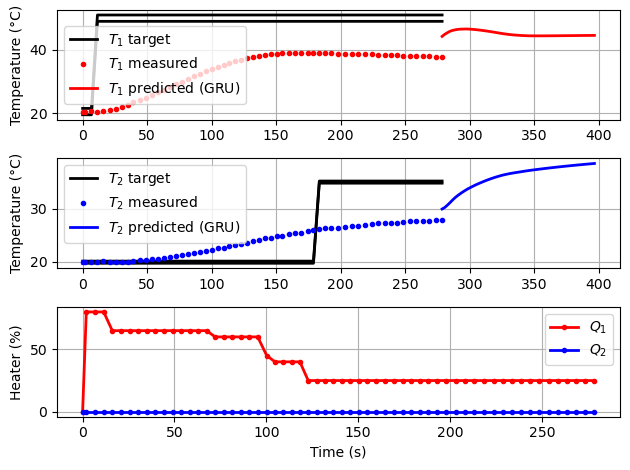

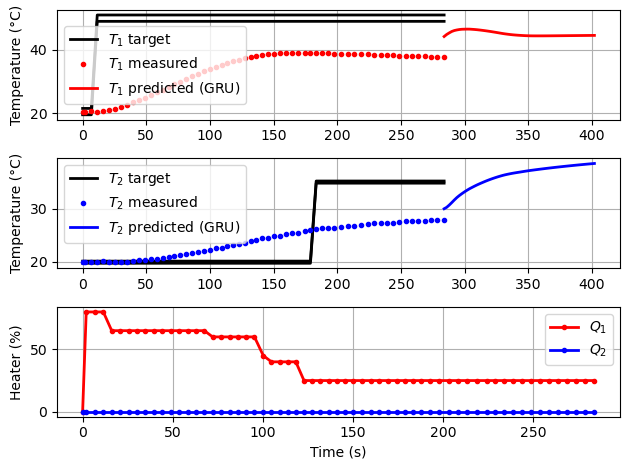

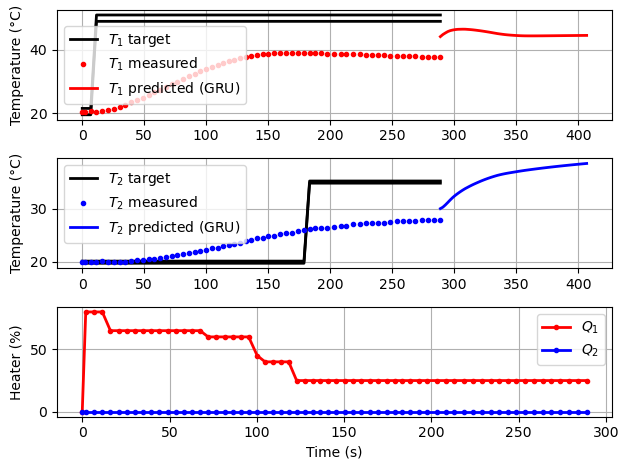

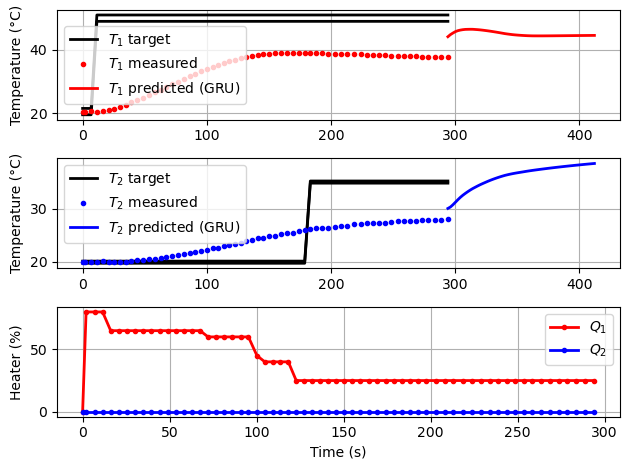

Messung abgebrochen.
TCLab disconnected successfully.


<Figure size 640x480 with 0 Axes>

Regeldaten gespeichert in: 12-TCLab_GRU_control.csv


In [34]:
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product
from tensorflow.keras.models import load_model
from tclab import TCLab

# ------------------------------------------------------------
# Gespeicherte Artefakte laden
# ------------------------------------------------------------
MODEL_FILE = "gru_tclab_model.keras"
XSCALER_FILE = "gru_x_scaler.gz"
YSCALER_FILE = "gru_y_scaler.gz"
META_FILE = "gru_tclab_meta.json"

model = load_model(MODEL_FILE)
x_scaler = joblib.load(XSCALER_FILE)
y_scaler = joblib.load(YSCALER_FILE)

with open(META_FILE, "r", encoding="utf-8") as f:
    meta = json.load(f)

WINDOW = int(meta["window"])

# ------------------------------------------------------------
# Regelungsparameter
# ------------------------------------------------------------
DT = 2.0
PRED_HORIZON = 60       # 60 Schritte = 120 s
DB1 = 1.0
DB2 = 0.2
WEIGHT_T1 = 1.0
WEIGHT_T2 = 1.0
MOVE_PENALTY = 0.02
HEATER_PENALTY = 0.0005

# ------------------------------------------------------------
# Hilfsfunktionen
# ------------------------------------------------------------
def scale_sequences(x_raw):
    x_scaled = x_scaler.transform(x_raw.reshape(-1, x_raw.shape[-1]))
    return x_scaled.reshape(x_raw.shape)

def predict_next_temperature(seq_raw_batch):
    x_scaled = scale_sequences(seq_raw_batch.astype(np.float32))
    y_scaled_pred = model.predict(x_scaled, verbose=0)
    return y_scaler.inverse_transform(y_scaled_pred)

def build_candidate_grid(q1_prev, q2_prev):
    q1_grid = np.unique(np.clip(
        np.array([0, 20, 40, 60, 80, 100, q1_prev, q1_prev - 15, q1_prev + 15]),
        0, 100
    ))
    q2_grid = np.unique(np.clip(
        np.array([0, 20, 40, 60, 80, 100, q2_prev, q2_prev - 15, q2_prev + 15]),
        0, 100
    ))
    return np.array(list(product(q1_grid, q2_grid)), dtype=np.float32)

def rollout_constant_candidates(seq_raw, candidate_actions, sp1_future, sp2_future,
                                prev_action=(0.0, 0.0)):
    n_candidates = len(candidate_actions)
    horizon = len(sp1_future)

    seq_batch = np.repeat(seq_raw[np.newaxis, :, :], n_candidates, axis=0).astype(np.float32)
    total_cost = np.zeros(n_candidates, dtype=np.float64)
    traj = np.zeros((n_candidates, horizon, 2), dtype=np.float32)

    q1_prev, q2_prev = prev_action
    total_cost += MOVE_PENALTY * (
        (candidate_actions[:, 0] - q1_prev) ** 2 +
        (candidate_actions[:, 1] - q2_prev) ** 2
    )
    total_cost += HEATER_PENALTY * (
        candidate_actions[:, 0] ** 2 + candidate_actions[:, 1] ** 2
    )

    for h in range(horizon):
        y_pred = predict_next_temperature(seq_batch)
        traj[:, h, :] = y_pred

        e1 = np.maximum(0.0, np.abs(y_pred[:, 0] - sp1_future[h]) - DB1)
        e2 = np.maximum(0.0, np.abs(y_pred[:, 1] - sp2_future[h]) - DB2)

        total_cost += WEIGHT_T1 * e1**2 + WEIGHT_T2 * e2**2

        new_row = np.column_stack([
            candidate_actions[:, 0],
            candidate_actions[:, 1],
            y_pred[:, 0],
            y_pred[:, 1]
        ]).astype(np.float32)

        seq_batch = np.concatenate([seq_batch[:, 1:, :], new_row[:, None, :]], axis=1)

    best_idx = int(np.argmin(total_cost))
    return best_idx, total_cost, traj

# ------------------------------------------------------------
# Hardware starten
# ------------------------------------------------------------
a = TCLab()

tf_min = 10
n = tf_min * 30 + 1

tm = np.zeros(n)
Q1s = np.zeros(n)
Q2s = np.zeros(n)
T1m = a.T1 * np.ones(n)
T2m = a.T2 * np.ones(n)
T1sp = T1m[0] * np.ones(n)
T2sp = T2m[0] * np.ones(n)

# Sollwerte wie im vorherigen MPC-Block
T1sp[3:] = 50.0
T2sp[40:] = 35.0
T1sp[80:] = 30.0
T2sp[120:] = 50.0
T1sp[160:] = 45.0
T2sp[200:] = 35.0
T1sp[240:] = 60.0

# Initiale Historie
seq_live = np.tile(np.array([0.0, 0.0, T1m[0], T2m[0]], dtype=np.float32), (WINDOW, 1))

start_time = time.time()
prev_time = start_time

plt.figure(figsize=(10, 7))
plt.ion()
plt.show()

try:
    for i in range(1, n):
        sleep = DT - (time.time() - prev_time)
        if sleep > 0:
            time.sleep(sleep)

        now = time.time()
        prev_time = now
        tm[i] = now - start_time

        # Messen
        T1m[i] = a.T1
        T2m[i] = a.T2

        # Historie aktualisieren
        seq_live = np.vstack([
            seq_live[1:],
            np.array([Q1s[i - 1], Q2s[i - 1], T1m[i], T2m[i]], dtype=np.float32)
        ])

        # Zukunftssollwerte
        end_idx = min(i + PRED_HORIZON, n)
        sp1_future = T1sp[i:end_idx]
        sp2_future = T2sp[i:end_idx]

        if len(sp1_future) < PRED_HORIZON:
            sp1_future = np.pad(sp1_future, (0, PRED_HORIZON - len(sp1_future)), mode="edge")
            sp2_future = np.pad(sp2_future, (0, PRED_HORIZON - len(sp2_future)), mode="edge")

        # Kandidaten testen
        actions = build_candidate_grid(Q1s[i - 1], Q2s[i - 1])
        best_idx, costs, traj = rollout_constant_candidates(
            seq_raw=seq_live,
            candidate_actions=actions,
            sp1_future=sp1_future,
            sp2_future=sp2_future,
            prev_action=(Q1s[i - 1], Q2s[i - 1])
        )

        Q1s[i] = float(actions[best_idx, 0])
        Q2s[i] = float(actions[best_idx, 1])

        # Stellgrößen setzen
        a.Q1(Q1s[i])
        a.Q2(Q2s[i])

        # Plot
        plt.clf()

        ax = plt.subplot(3, 1, 1)
        ax.grid()
        plt.plot(tm[:i + 1], T1sp[:i + 1] + DB1, "k-", linewidth=2, label=r"$T_1$ target")
        plt.plot(tm[:i + 1], T1sp[:i + 1] - DB1, "k-", linewidth=2)
        plt.plot(tm[:i + 1], T1m[:i + 1], "r.", label=r"$T_1$ measured")
        plt.plot(
            tm[i] + np.arange(PRED_HORIZON) * DT,
            traj[best_idx, :, 0],
            "r-",
            linewidth=2,
            label=r"$T_1$ predicted (GRU)"
        )
        plt.ylabel("Temperature (°C)")
        plt.legend(loc="best")

        ax = plt.subplot(3, 1, 2)
        ax.grid()
        plt.plot(tm[:i + 1], T2sp[:i + 1] + DB2, "k-", linewidth=2, label=r"$T_2$ target")
        plt.plot(tm[:i + 1], T2sp[:i + 1] - DB2, "k-", linewidth=2)
        plt.plot(tm[:i + 1], T2m[:i + 1], "b.", label=r"$T_2$ measured")
        plt.plot(
            tm[i] + np.arange(PRED_HORIZON) * DT,
            traj[best_idx, :, 1],
            "b-",
            linewidth=2,
            label=r"$T_2$ predicted (GRU)"
        )
        plt.ylabel("Temperature (°C)")
        plt.legend(loc="best")

        ax = plt.subplot(3, 1, 3)
        ax.grid()
        plt.plot(tm[:i + 1], Q1s[:i + 1], "r.-", linewidth=2, label=r"$Q_1$")
        plt.plot(tm[:i + 1], Q2s[:i + 1], "b.-", linewidth=2, label=r"$Q_2$")
        plt.ylabel("Heater (%)")
        plt.xlabel("Time (s)")
        plt.legend(loc="best")

        plt.tight_layout()
        plt.draw()
        plt.pause(0.05)

except KeyboardInterrupt:
    print("Messung abgebrochen.")

finally:
    a.Q1(0)
    a.Q2(0)
    a.close()

    results = pd.DataFrame({
        "Time": tm,
        "Q1": Q1s,
        "Q2": Q2s,
        "T1": T1m,
        "T2": T2m,
        "T1sp": T1sp,
        "T2sp": T2sp
    })
    results.to_csv("12-TCLab_GRU_control.csv", index=False)
    plt.savefig("12-TCLab_GRU_control.png", dpi=150)
    plt.show()

    print("Regeldaten gespeichert in: 12-TCLab_GRU_control.csv")